<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EA%B9%80%EB%AF%BC%EC%A0%9C/ELEalgo_model_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ELEalgo — SOH 모델 평가 노트북 (전체 feature, 편견 없이)

팀장님이 공지한 **4가지 평가 기준**에 맞춰 모델을 만들고 비교하는 노트북.
다음 세션에서 메인 모델을 고를 때 쓰는 근거 자료를 뽑는 것이 목적.

| # | 평가 기준 | 이 노트북에서 보는 곳 |
|---|---|---|
| 1 | **모델 정확도** — MSE · MAE · R² · Error rate | §5 CV 결과표, §6 Holdout 결과표 |
| 2 | **모델 간편성 / 이해도** | §4 모델 스펙표(파라미터 수·구조), §8 Feature importance |
| 3 | **시각화** — predicted vs actual · feature importance · loss curve | §2 EDA, §5~§8 전부 |
| 4 | **모델 속도** | §9 학습 시간 · 추론 시간 표/그래프 |

**설계 원칙**
- feature는 CSV에 있는 **25개 전부** 넣는다. 미리 빼지 않는다. (나중에 결과 보고 `EXCLUDE` 리스트에 추가해서 빼면 됨)
- split은 **셀 단위**(`GroupKFold`)로만 한다. 같은 셀의 RPT가 train/test 양쪽에 있으면 성능이 부풀려진다.
- 비교 모델 4개: `Ridge`(선형, 가장 단순) · `RandomForest` · `GradientBoosting` · `MLP`(우리 FPGA 타깃 구조 N→16→8→1)
- 그림 제목/축은 영어 (Colab 기본 폰트에 한글 없음). 설명은 주석에 한글로.

**실행 시간**: CPU 기준 3~5분 (옵션 `RUN_DROP_ONE=True`면 +10분)


# §0. 환경 설정 (Config)

In [3]:
# ── 라이브러리 ────────────────────────────────────────────────────────────────
import os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3

# ── 실험 설정 ────────────────────────────────────────────────────────────────
CONFIG = {
    # MLP 학습
    "batch_size": 16,         # 141행이라 작은 batch. (기존 뼈대 100 → 한 epoch에 1~2 step밖에 안 돼서 줄임)
    "epochs": 2000,           # 최대 epoch. early stopping이 보통 300~800에서 멈춤
    "learning_rate": 3e-3,
    "weight_decay": 1e-4,     # L2 규제. feature 25개 vs 행 141개라 과적합 방지 필요
    "patience": 100,          # val loss가 100 epoch 동안 안 좋아지면 중단
    "lr_patience": 30,        # 30 epoch 정체 시 lr 절반
    # 데이터 분할
    "n_folds": 5,             # 셀 단위 5-fold CV
    "test_size": 0.2,         # holdout 셀 비율 (24셀 → 5셀)
    "random_seed": 42,
}

# ── 옵션 스위치 (시간 오래 걸리는 분석) ──────────────────────────────────────
RUN_DROP_ONE       = False   # True: feature 하나씩 빼고 CV 재학습 (25 × 5 fold MLP → 약 10분)
RUN_LEARNING_CURVE = True    # True: 학습 데이터 양 vs 성능 곡선 (약 1분)

def set_seed(seed):
    # 재현성: 파이썬/넘파이/토치 시드를 한 번에 고정
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(CONFIG["random_seed"])
torch.set_num_threads(2)          # Colab CPU 2코어. 스레드 많이 잡으면 오히려 느려짐
print("torch", torch.__version__, "| device: cpu")

torch 2.11.0+cpu | device: cpu


# §1. 데이터 로드 & Feature 정의

**feature는 CSV의 25개 컬럼 전부.** 메타데이터 3개(`cell_global_id`, `rpt_id`, `aging_condition`)와 라벨(`soh_label_pct`)만 제외.

`FEATURE_GROUPS`는 **제외용이 아니라 시각화 색 구분용**이다. 그래프에서 어느 계열 feature인지 한눈에 보기 위함.

나중에 특정 feature를 빼고 싶으면 `EXCLUDE` 리스트에 이름만 추가하고 노트북을 다시 돌리면 된다.


In [4]:
# ── 파일 경로 (Colab Drive 우선, 없으면 로컬) ─────────────────────────────────
DRIVE_PATH = "/content/drive/MyDrive/merged_features_25C.csv"
LOCAL_PATH = "merged_features_25C.csv"

if os.path.exists(DRIVE_PATH):
    CSV_FILENAME = DRIVE_PATH
elif os.path.exists(LOCAL_PATH):
    CSV_FILENAME = LOCAL_PATH
else:
    from google.colab import drive       # Colab에서 Drive 안 붙어 있으면 여기서 마운트 팝업
    drive.mount("/content/drive")
    CSV_FILENAME = DRIVE_PATH

# ── 컬럼 역할 정의 ────────────────────────────────────────────────────────────
META   = ["cell_global_id", "rpt_id", "aging_condition"]   # 학습에 안 씀 (식별용)
TARGET = "soh_label_pct"                                   # 라벨: SOH (%)
GROUP  = "cell_global_id"                                  # split 기준: 셀 ID

# ★ 나중에 제외할 feature는 여기에 이름만 추가 (지금은 비워둔다 = 25개 전부 사용)
#   예) EXCLUDE = ["ccct", "range", "stdev"]
EXCLUDE = []

# ── 시각화용 feature 계열 (색 구분에만 쓰임) ──────────────────────────────────
FEATURE_GROUPS = {
    # ΔQ(V) 곡선 통계 (0.2C 충전 − 1C 충전 용량 차이 곡선). 논문(Severson류) 계열
    "dQ":   ["variance", "xmean", "mean3839", "mean3940", "mean4041", "mean4142",
             "max", "min", "range", "stdev"],
    # DC 내부저항. dcirohm = 1C 방전펄스, dcir_socXX = GITT 0.6A 충전펄스 (SOC별)
    "DCIR": ["dcirohm", "dcir_soc00ohm", "dcir_soc10ohm", "dcir_soc20ohm", "dcir_soc30ohm",
             "dcir_soc40ohm", "dcir_soc50ohm", "dcir_soc60ohm", "dcir_soc70ohm", "dcir_soc80ohm"],
    # 충전 시간 계열. deltat = 3.8→4.0V 통과 시간, ctr = 비율, ccct/cvct = CC/CV 구간 시간
    "Time": ["deltat023840", "deltat103840", "ctr", "ccct", "cvct"],
}
GROUP_COLOR = {"dQ": "#1f77b4", "DCIR": "#d62728", "Time": "#2ca02c"}   # 파랑/빨강/초록

def feat_group(f):
    # feature 이름 → 계열 이름
    for g, lst in FEATURE_GROUPS.items():
        if f in lst: return g
    return "other"

# ── 로드 ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_FILENAME, encoding="utf-8-sig")   # BOM 있는 CSV라 utf-8-sig
# "LOW C@ 25°C #3" → "LOW C@ 25°C" (셀 번호 떼서 조건명만)
df["cond"] = df["aging_condition"].str.replace(r"\s*#\d+$", "", regex=True)

# feature = 전체 컬럼 − META − TARGET − cond − EXCLUDE
FEATURES = [c for c in df.columns if c not in META + [TARGET, "cond"] + EXCLUDE]
N_FEAT = len(FEATURES)

X_all = df[FEATURES].values.astype(np.float32)
y_all = df[TARGET].values.astype(np.float32)
g_all = df[GROUP].values

print(f"CSV: {CSV_FILENAME}")
print(f"행 {len(df)} / 셀 {df[GROUP].nunique()} / 조건 {df['cond'].nunique()}")
print(f"feature {N_FEAT}개 (제외 {len(EXCLUDE)}개: {EXCLUDE})")
for g, lst in FEATURE_GROUPS.items():
    print(f"  [{g:4s}] {[f for f in lst if f in FEATURES]}")
print()
print("조건별 행 수:")
print(df["cond"].value_counts().to_string())
print()
print("결측치:", int(df[FEATURES].isna().sum().sum()), "개")
df[FEATURES + [TARGET]].describe().T.round(4)

CSV: merged_features_25C.csv
행 141 / 셀 24 / 조건 5
feature 25개 (제외 0개: [])
  [dQ  ] ['variance', 'xmean', 'mean3839', 'mean3940', 'mean4041', 'mean4142', 'max', 'min', 'range', 'stdev']
  [DCIR] ['dcirohm', 'dcir_soc00ohm', 'dcir_soc10ohm', 'dcir_soc20ohm', 'dcir_soc30ohm', 'dcir_soc40ohm', 'dcir_soc50ohm', 'dcir_soc60ohm', 'dcir_soc70ohm', 'dcir_soc80ohm']
  [Time] ['deltat023840', 'deltat103840', 'ctr', 'ccct', 'cvct']

조건별 행 수:
cond
LOW C@ 25°C     57
4.35V@ 25°C     24
HIGH C@ 25°C    22
1V@ 25°C        20
4.5V@ 25°C      18

결측치: 0 개


,count,mean,std,min,25%,50%,75%,max
variance,141.0,0.0119,0.0037,0.0067,0.0092,0.0110,0.0141,0.0216
xmean,141.0,0.3245,0.0319,0.2836,0.3000,0.3156,0.3452,0.4245
mean3839,141.0,0.2721,0.0253,0.2293,0.2547,0.2690,0.2889,0.3443
mean3940,141.0,0.3185,0.0332,0.2756,0.2909,0.3092,0.3421,0.4192
mean4041,141.0,0.2753,0.0402,0.2311,0.2444,0.2579,0.3005,0.4193
mean4142,141.0,0.4374,0.0314,0.3688,0.4133,0.4298,0.4524,0.5328
max,141.0,0.4983,0.0350,0.4365,0.4720,0.4901,0.5188,0.5998
min,141.0,0.2518,0.0299,0.2155,0.2271,0.2401,0.2746,0.3375
range,141.0,0.2464,0.0122,0.2164,0.2375,0.2475,0.2546,0.2947
stdev,141.0,0.0763,0.0038,0.0627,0.0740,0.0762,0.0788,0.0867


# §2. 탐색적 시각화 (EDA)

모델 돌리기 전에 데이터 자체를 본다. 여기서 이미
- 어떤 feature가 SOH와 강하게 움직이는지 (단조 관계 → Spearman)
- 어떤 feature끼리 사실상 같은 정보인지 (상관 heatmap)
- 라벨 분포가 어디에 몰려 있는지
가 보인다. §8 feature importance 결과와 같이 보면 "왜 그 feature가 중요하게 나왔는지" 설명할 수 있다.


## 2-1. 라벨(SOH) 분포 & 셀별 열화 궤적

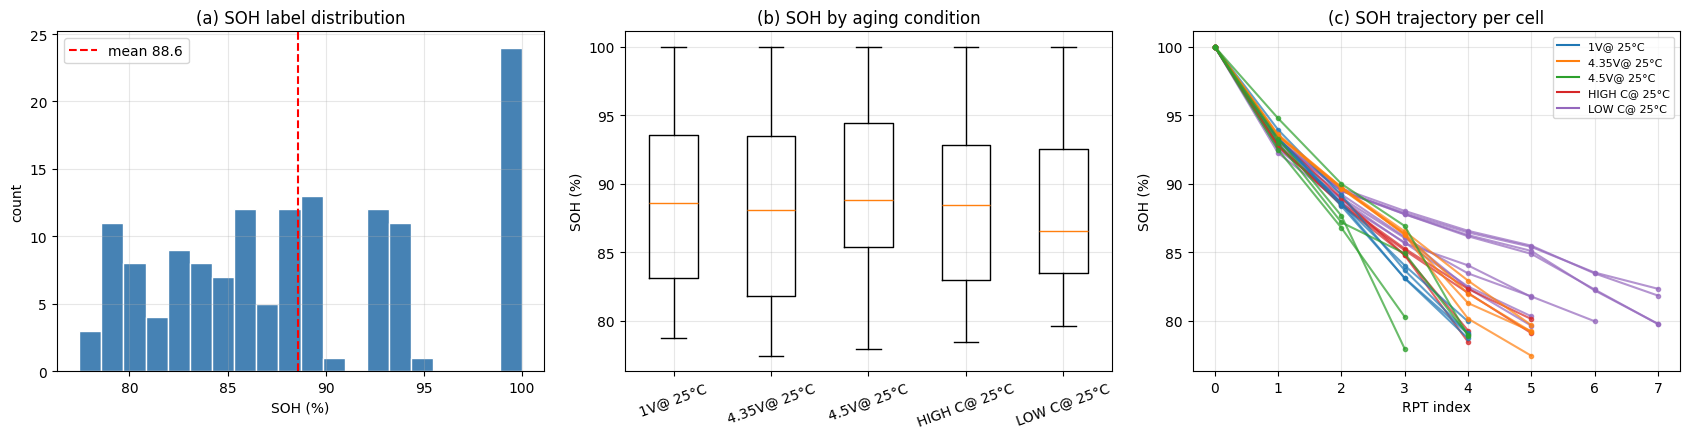

셀당 RPT 개수: {6: 9, 5: 8, 8: 4, 4: 2, 7: 1}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) SOH 히스토그램 — 라벨이 어느 구간에 몰려 있는지. 80% 아래는 거의 없음 → 그 구간 예측은 신뢰도 낮다
ax = axes[0]
ax.hist(y_all, bins=20, color="steelblue", edgecolor="white")
ax.axvline(y_all.mean(), color="red", ls="--", label=f"mean {y_all.mean():.1f}")
ax.set_xlabel("SOH (%)"); ax.set_ylabel("count"); ax.set_title("(a) SOH label distribution"); ax.legend()

# (b) 조건별 SOH 박스플롯 — 조건마다 열화 깊이가 다름 (4.5V 과충전 조건이 가장 많이 열화)
ax = axes[1]
conds = sorted(df["cond"].unique())
ax.boxplot([df.loc[df["cond"] == c, TARGET] for c in conds], labels=conds)
ax.set_ylabel("SOH (%)"); ax.set_title("(b) SOH by aging condition")
ax.tick_params(axis="x", rotation=20)

# (c) 셀별 SOH 궤적 (x = RPT 번호) — 조건별 색. 같은 색 선이 여러 개 = 같은 조건의 셀들
ax = axes[2]
cond_colors = dict(zip(conds, plt.cm.tab10.colors))
for cid, cdf in df.groupby(GROUP):
    c = cdf["cond"].iloc[0]
    ax.plot(cdf["rpt_id"], cdf[TARGET], "-o", ms=3, alpha=.7, color=cond_colors[c])
for c in conds: ax.plot([], [], color=cond_colors[c], label=c)   # 범례용 더미
ax.set_xlabel("RPT index"); ax.set_ylabel("SOH (%)"); ax.set_title("(c) SOH trajectory per cell"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("셀당 RPT 개수:", df.groupby(GROUP).size().value_counts().to_dict())

## 2-2. Feature vs SOH 산점도 (25개 전부)

각 칸: x = feature, y = SOH, 색 = 조건. 제목의 ρ = Spearman 순위상관.
- |ρ| 크고 **조건별로 같은 방향**이면 좋은 feature.
- 조건에 따라 점 구름이 따로 놀면 (예: 색깔별로 층이 지면) 조건 정보 없이는 쓰기 어려운 feature.


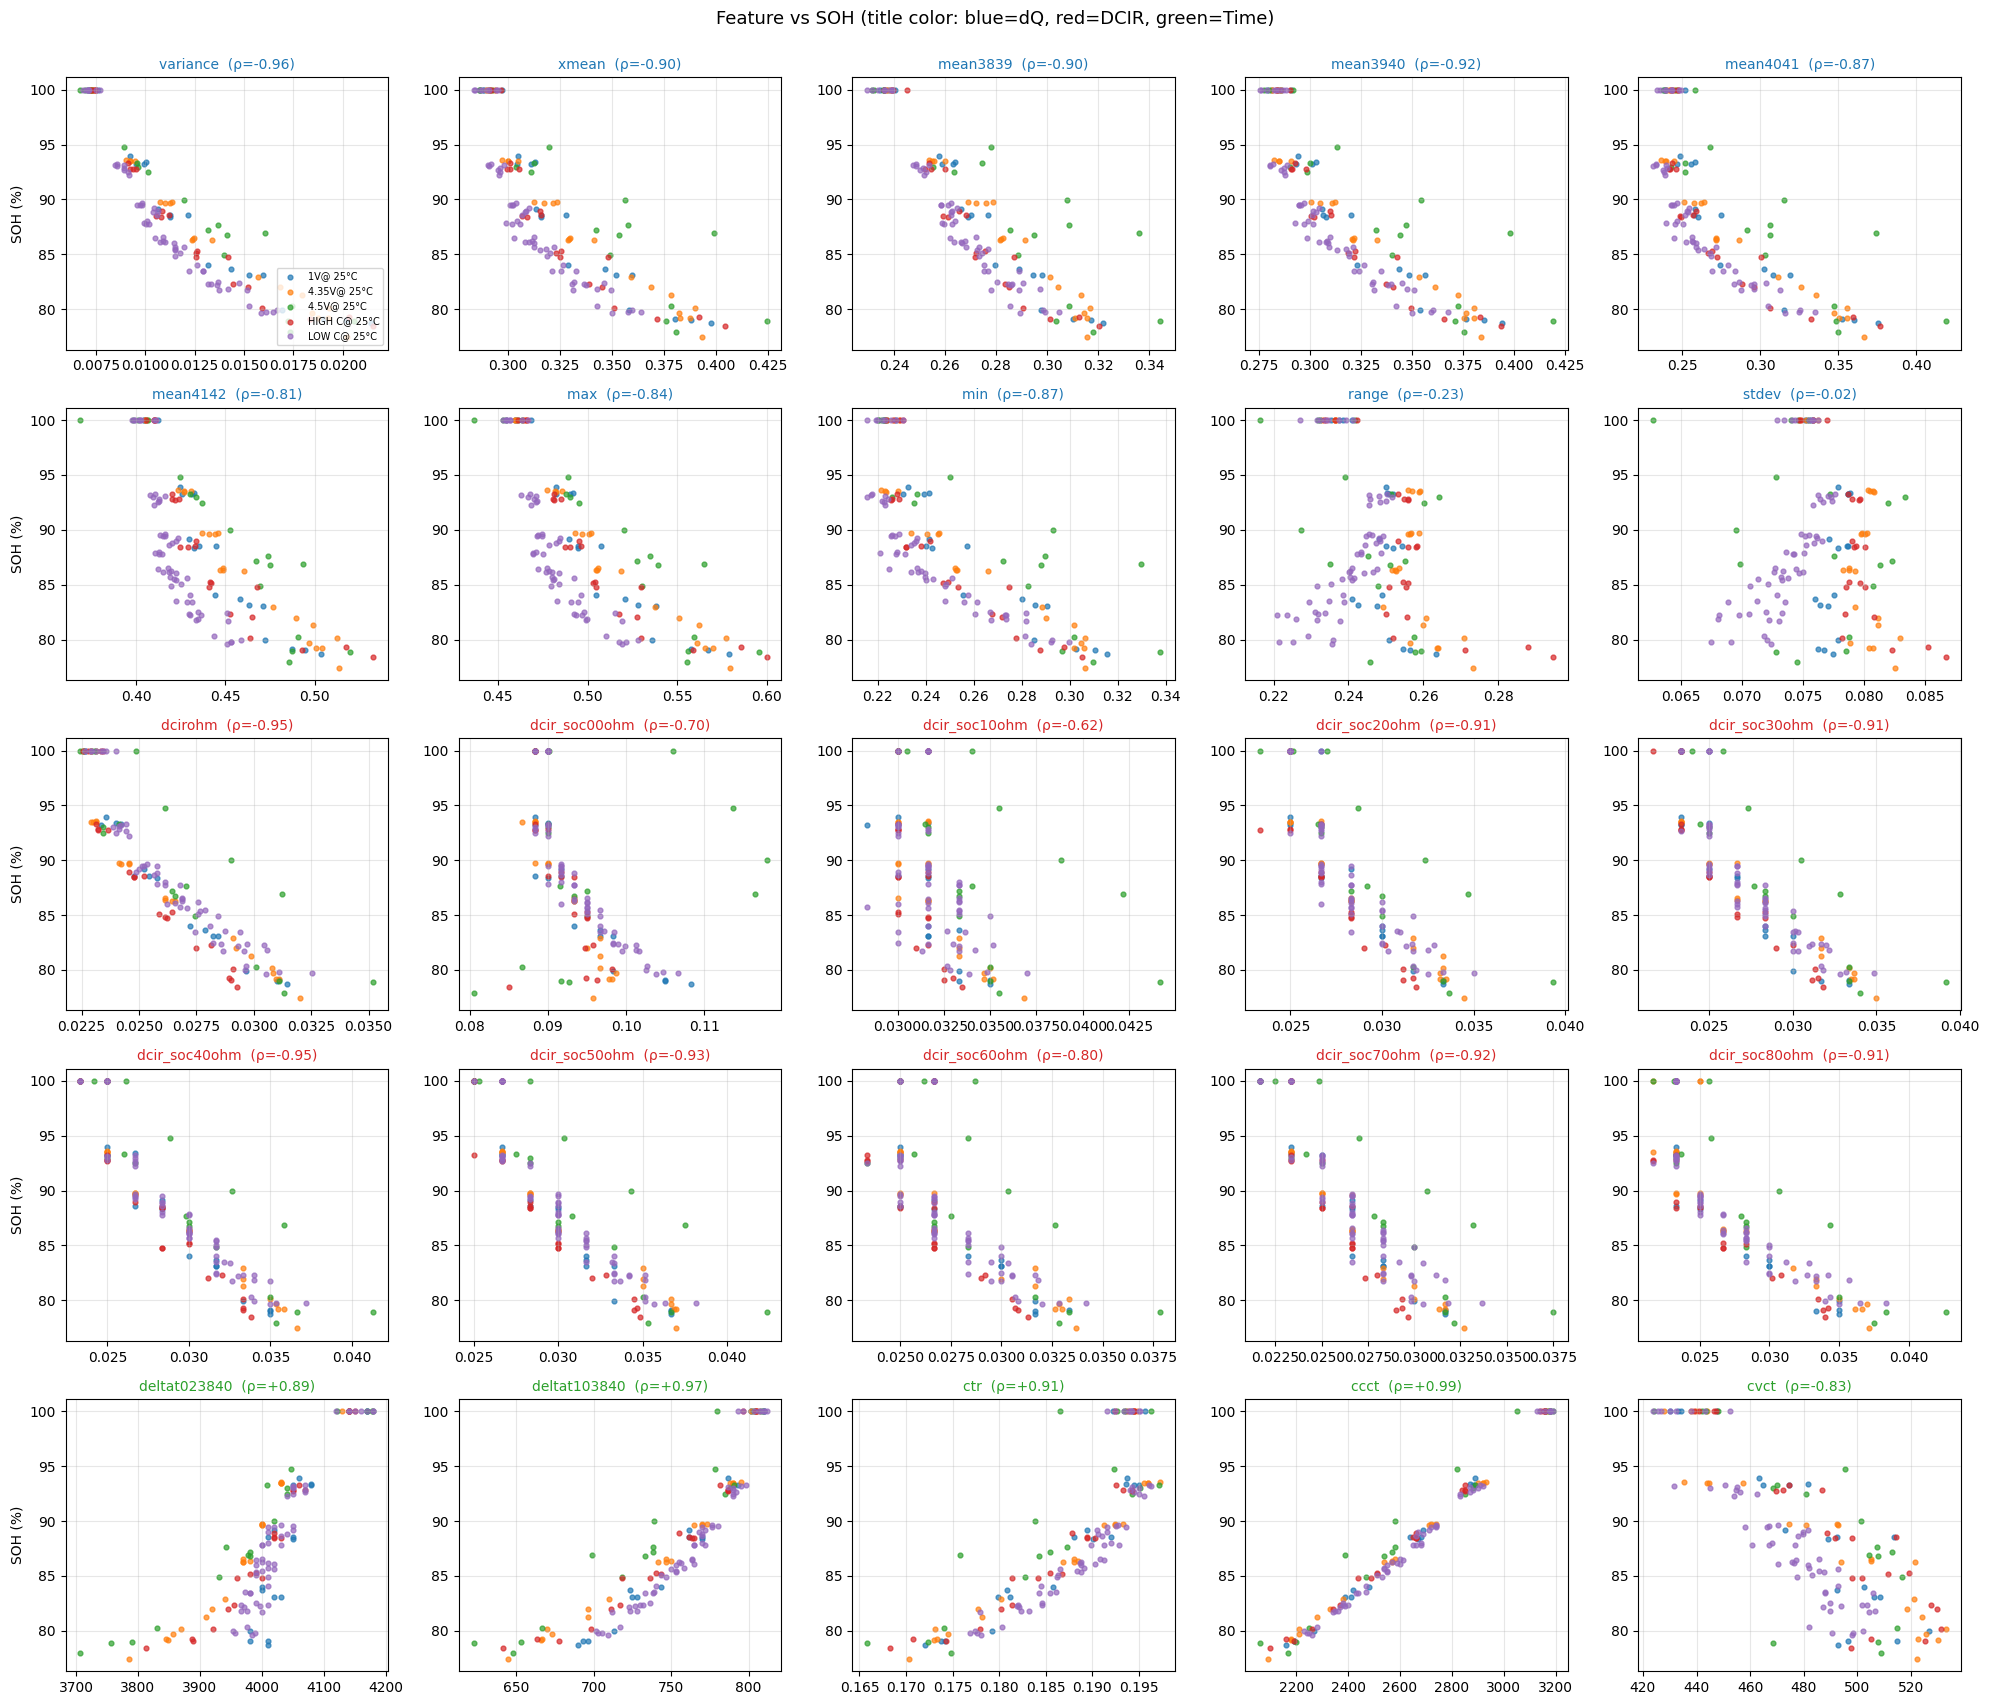

In [6]:
n_cols = 5
n_rows = int(np.ceil(N_FEAT / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.4 * n_rows))
axes = axes.flatten()

spearman = {}   # §8에서 feature importance와 같이 보기 위해 저장
for i, f in enumerate(FEATURES):
    ax = axes[i]
    for c in conds:
        m = df["cond"] == c
        ax.scatter(df.loc[m, f], df.loc[m, TARGET], s=12, alpha=.7, color=cond_colors[c], label=c)
    rho, _ = spearmanr(df[f], df[TARGET])
    spearman[f] = rho
    ax.set_title(f"{f}  (ρ={rho:+.2f})", fontsize=10, color=GROUP_COLOR[feat_group(f)])
    ax.set_xlabel(""); ax.set_ylabel("SOH (%)" if i % n_cols == 0 else "")
for j in range(i + 1, len(axes)): axes[j].axis("off")
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("Feature vs SOH (title color: blue=dQ, red=DCIR, green=Time)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

## 2-3. SOH와의 Spearman 상관 순위

단순히 "혼자서 SOH를 얼마나 잘 따라가나"의 순위. 모델 importance(§8)와 순위가 크게 다르면 그 이유(중복 정보, 비선형 등)를 따져볼 가치가 있다.


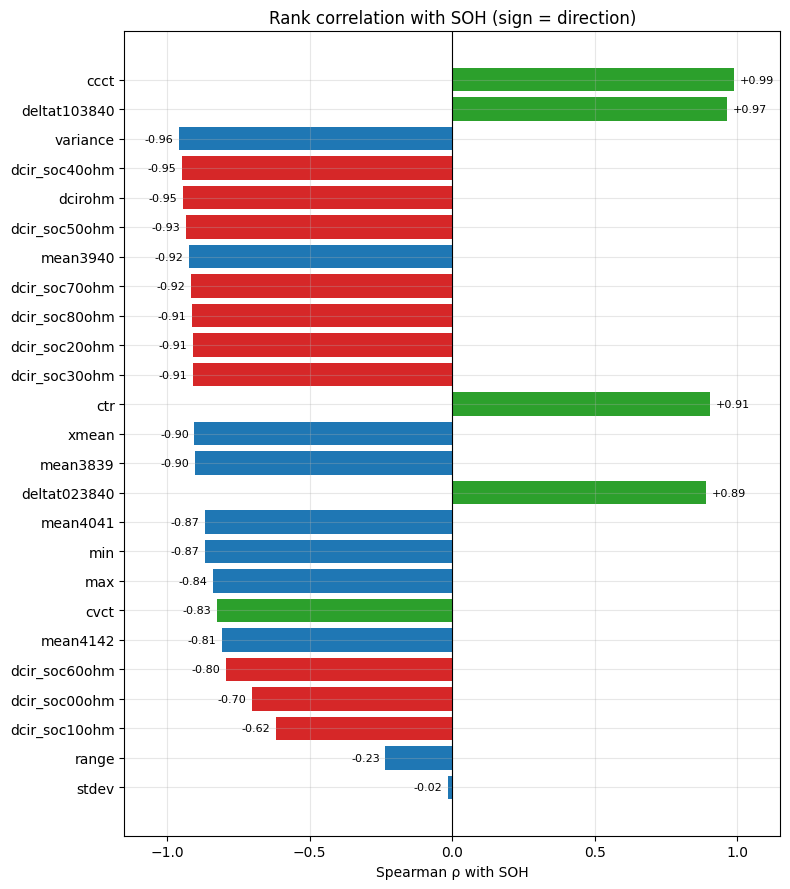

In [7]:
sp = pd.Series(spearman).reindex(FEATURES)
order = sp.abs().sort_values(ascending=True).index          # |ρ| 오름차순 → 그래프 위쪽이 큰 값

fig, ax = plt.subplots(figsize=(8, 0.32 * N_FEAT + 1))
ax.barh(order, sp[order], color=[GROUP_COLOR[feat_group(f)] for f in order])
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Spearman ρ with SOH"); ax.set_title("Rank correlation with SOH (sign = direction)")
for f in order:                                              # 막대 끝에 값 표시
    ax.text(sp[f] + (0.02 if sp[f] >= 0 else -0.02), f, f"{sp[f]:+.2f}",
            va="center", ha="left" if sp[f] >= 0 else "right", fontsize=8)
ax.set_xlim(-1.15, 1.15)
plt.tight_layout(); plt.show()

## 2-4. Feature 간 상관 Heatmap

같은 계열 안에서 |r| ≈ 1인 쌍이 많다 = 사실상 같은 정보 → 모델 간편성 관점에서 나중에 하나만 남겨도 됨.
마지막 행/열이 SOH.


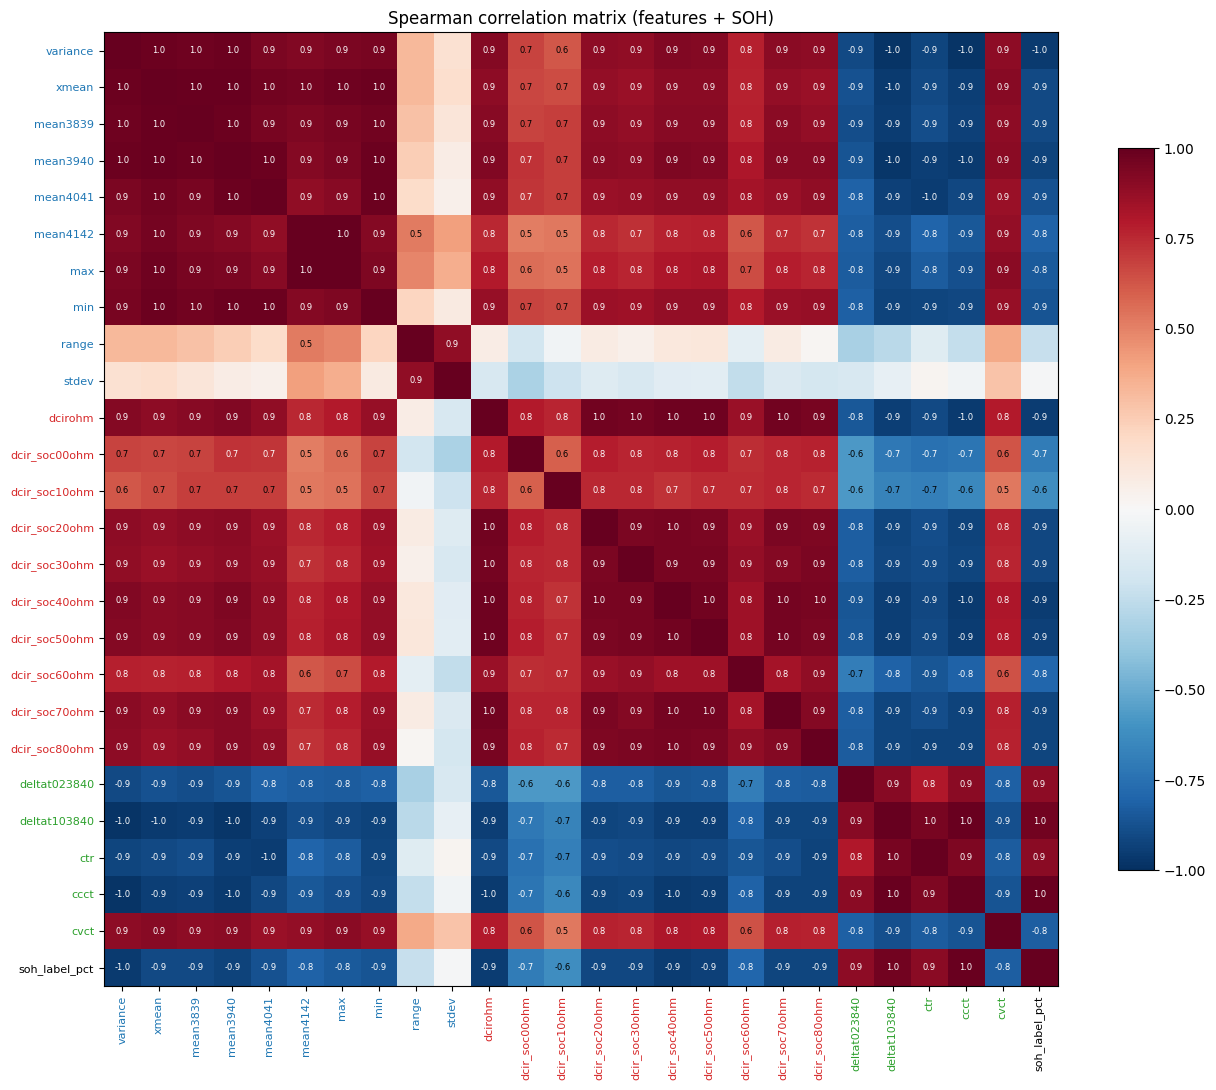

|ρ| ≥ 0.95 인 feature 쌍 35개 (사실상 중복 정보 → 간편성 위해 하나만 남겨도 됨):
  mean4142       ~ max             ρ=+0.994
  xmean          ~ mean3839        ρ=+0.991
  xmean          ~ mean3940        ρ=+0.989
  deltat103840   ~ ccct            ρ=+0.987
  mean3839       ~ mean3940        ρ=+0.981
  mean4041       ~ min             ρ=+0.981
  variance       ~ xmean           ρ=+0.980
  variance       ~ deltat103840    ρ=-0.979
  xmean          ~ min             ρ=+0.979
  mean3940       ~ mean4041        ρ=+0.979
  variance       ~ ccct            ρ=-0.978
  variance       ~ mean3940        ρ=+0.977
  mean3940       ~ min             ρ=+0.977
  dcirohm        ~ dcir_soc50ohm   ρ=+0.974
  dcirohm        ~ dcir_soc40ohm   ρ=+0.972
  xmean          ~ max             ρ=+0.971
  mean3940       ~ deltat103840    ρ=-0.971
  variance       ~ mean3839        ρ=+0.970
  dcirohm        ~ dcir_soc70ohm   ρ=+0.968
  mean3839       ~ min             ρ=+0.966
  xmean          ~ mean4041        ρ=+0.965
  dcirohm        

In [8]:
corr = df[FEATURES + [TARGET]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8); ax.set_yticklabels(corr.columns, fontsize=8)
# 축 라벨 색 = 계열
for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    t = lbl.get_text(); lbl.set_color("black" if t == TARGET else GROUP_COLOR[feat_group(t)])
# 셀 안에 숫자 (|r| ≥ 0.5만, 너무 빽빽하지 않게)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.5 and i != j:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6, color="white" if abs(v) > .7 else "black")
ax.grid(False)
plt.colorbar(im, fraction=0.03); ax.set_title("Spearman correlation matrix (features + SOH)")
plt.tight_layout(); plt.show()

# 중복 정보 후보: |r| ≥ 0.95인 feature 쌍 나열
pairs = []
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) >= 0.95: pairs.append((a, b, round(r, 3)))
print(f"|ρ| ≥ 0.95 인 feature 쌍 {len(pairs)}개 (사실상 중복 정보 → 간편성 위해 하나만 남겨도 됨):")
for a, b, r in sorted(pairs, key=lambda t: -abs(t[2])): print(f"  {a:14s} ~ {b:14s}  ρ={r:+.3f}")

# §3. 데이터 분할 — 셀 단위

- **Holdout test**: 셀 20% (≈5셀). 마지막 §6에서 딱 한 번 평가.
- **Dev(나머지 80%)**: `GroupKFold(5)`로 CV. 모델 비교·feature importance는 전부 여기서.

행 단위 `train_test_split`을 쓰면 같은 셀의 RPT 3번이 train, RPT 4번이 test에 들어가서 모델이 "그 셀"을 외운다. 그래서 반드시 셀 단위.


Dev : 109 rows / 19 cells
Test:  32 rows / 5 cells -> cell id [np.int64(1), np.int64(9), np.int64(12), np.int64(17), np.int64(19)]
Test 셀의 조건: {1: 'LOW C@ 25°C', 9: 'HIGH C@ 25°C', 12: 'HIGH C@ 25°C', 17: '4.35V@ 25°C', 19: '4.35V@ 25°C'}


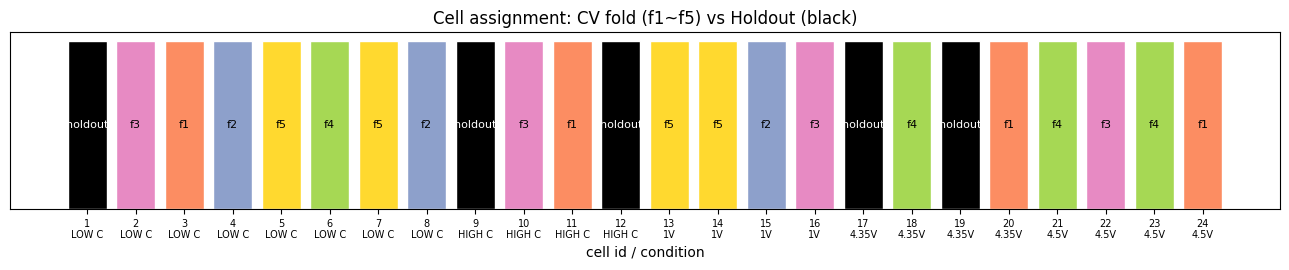

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=CONFIG["test_size"], random_state=CONFIG["random_seed"])
dev_idx, test_idx = next(gss.split(X_all, y_all, groups=g_all))

X_dev, y_dev, g_dev = X_all[dev_idx], y_all[dev_idx], g_all[dev_idx]
X_test, y_test, g_test = X_all[test_idx], y_all[test_idx], g_all[test_idx]
df_dev, df_test = df.iloc[dev_idx].copy(), df.iloc[test_idx].copy()

print(f"Dev : {len(X_dev):3d} rows / {len(np.unique(g_dev))} cells")
print(f"Test: {len(X_test):3d} rows / {len(np.unique(g_test))} cells -> cell id {sorted(np.unique(g_test))}")
print("Test 셀의 조건:", df_test.groupby(GROUP)["cond"].first().to_dict())

# CV fold 미리 만들어 두기 (모든 모델이 같은 fold를 써야 공정 비교)
gkf = GroupKFold(n_splits=CONFIG["n_folds"])
FOLDS = list(gkf.split(X_dev, y_dev, groups=g_dev))

# ── 분할 시각화: 셀 × 역할 (train fold 번호 / holdout) ─────────────────────────
cell_role = pd.Series("holdout", index=sorted(np.unique(g_all)))
for k, (tr, va) in enumerate(FOLDS, 1):
    for cid in np.unique(g_dev[va]): cell_role[cid] = f"fold{k}"
role_colors = {"holdout": "black", **{f"fold{k}": plt.cm.Set2(k) for k in range(1, 6)}}

fig, ax = plt.subplots(figsize=(13, 2.8))
cell_cond = df.groupby(GROUP)["cond"].first()
for i, cid in enumerate(cell_role.index):
    ax.bar(i, 1, color=role_colors[cell_role[cid]], edgecolor="white")
    ax.text(i, 0.5, cell_role[cid].replace("fold", "f"), ha="center", va="center", fontsize=8,
            color="white" if cell_role[cid] == "holdout" else "black")
ax.set_xticks(range(len(cell_role))); ax.set_xticklabels([f"{cid}\n{cell_cond[cid].split('@')[0]}" for cid in cell_role.index], fontsize=7)
ax.set_yticks([]); ax.set_xlabel("cell id / condition"); ax.set_title("Cell assignment: CV fold (f1~f5) vs Holdout (black)")
ax.grid(False); plt.tight_layout(); plt.show()

# §4. 모델 정의 & 스펙표 (평가기준 2: 간편성/이해도)

| 모델 | 한 줄 설명 | FPGA 구현 |
|---|---|---|
| `Ridge` | 선형회귀 + L2. 가장 단순. y = w·x + b | 매우 쉬움 (곱셈 N번 + 덧셈) |
| `RandomForest` | 결정트리 200개 평균 | 어려움 (트리 순회, 메모리 큼) |
| `GradBoost` | 얕은 트리(depth 2) 300개 순차 합 | 어려움 |
| `MLP` | N→16→8→1, ReLU. **우리 FPGA 타깃 구조** | 목표 구조 (곱셈 16N+136, int8 가능) |

MLP는 학습 함수(`train_mlp`)를 따로 두고, sklearn 모델은 `.fit/.predict` 그대로 쓴다.


In [10]:
# ═══════════════════════════ MLP (PyTorch) ═══════════════════════════════════
class BatteryCSVDataset(Dataset):
    # (X, y) numpy → torch 텐서. y는 (N,1) 모양으로
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

class SOHPredictorMLP(nn.Module):
    # 구조 고정: input_dim → 16 → 8 → 1  (FPGA 팀과 합의된 크기)
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8),         nn.ReLU(),
            nn.Linear(8, 1),
        )
    def forward(self, x): return self.network(x)

def count_params(m): return sum(p.numel() for p in m.parameters())

# ── 타깃 스케일링 ─────────────────────────────────────────────────────────────
# SOH(77~100)를 그대로 회귀하면 초기 loss가 수천 → 학습 초반이 느리고 불안정.
# (y − 90)/10 으로 바꿔서 대략 −1.3 ~ +1 범위로 만들어 학습, 평가 때 되돌린다.
Y_OFFSET, Y_SCALE = 90.0, 10.0
def y_enc(y): return (y - Y_OFFSET) / Y_SCALE
def y_dec(z): return z * Y_SCALE + Y_OFFSET

def train_mlp(X_tr, y_tr, X_va, y_va, cfg=None, verbose=False):
    '''MLP 한 번 학습. 반환: (model, scaler, hist, best_epoch)
    - scaler: StandardScaler (train으로만 fit → val/test 누설 방지)
    - hist  : epoch별 train/val loss, lr  → loss curve 그리기용
    - early stopping: val loss 최저 시점의 weight로 복원
    '''
    cfg = {**CONFIG, **(cfg or {})}
    scaler = StandardScaler().fit(X_tr)
    Xtr, Xva = scaler.transform(X_tr), scaler.transform(X_va)
    tr_loader = DataLoader(BatteryCSVDataset(Xtr, y_enc(y_tr)), batch_size=cfg["batch_size"], shuffle=True)
    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(y_enc(y_va), dtype=torch.float32).unsqueeze(1)

    model = SOHPredictorMLP(X_tr.shape[1])
    crit  = nn.MSELoss()
    opt   = optim.Adam(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=cfg["lr_patience"])

    best, best_state, best_ep, wait = float("inf"), None, 0, 0
    hist = {"train": [], "val": [], "lr": []}
    for ep in range(1, cfg["epochs"] + 1):
        # --- train step ---
        model.train(); tl = 0.0
        for bx, by in tr_loader:
            opt.zero_grad()
            loss = crit(model(bx), by)
            loss.backward(); opt.step()
            tl += loss.item()
        tl /= len(tr_loader)
        # --- validation ---
        model.eval()
        with torch.no_grad(): vl = crit(model(Xva_t), yva_t).item()
        sched.step(vl)
        hist["train"].append(tl); hist["val"].append(vl); hist["lr"].append(opt.param_groups[0]["lr"])
        # --- early stopping 체크 ---
        if vl < best - 1e-6:
            best, best_ep, wait = vl, ep, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if verbose and ep % 100 == 0: print(f"  ep {ep:4d}  train {tl:.4f}  val {vl:.4f}  lr {hist['lr'][-1]:.1e}")
        if wait >= cfg["patience"]: break
    model.load_state_dict(best_state)
    return model, scaler, hist, best_ep

def mlp_predict(model, scaler, X):
    model.eval()
    with torch.no_grad():
        z = model(torch.tensor(scaler.transform(X), dtype=torch.float32)).numpy().flatten()
    return y_dec(z)

# ═══════════════════════════ sklearn 비교 모델 ════════════════════════════════
def make_sklearn_models(seed):
    # 매 fold마다 새 객체를 만들어야 하므로 함수로
    return {
        "Ridge":        make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1),
        "GradBoost":    GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.05,
                                                  subsample=0.8, random_state=seed),
    }
MODEL_NAMES  = ["Ridge", "RandomForest", "GradBoost", "MLP"]
MODEL_COLORS = dict(zip(MODEL_NAMES, ["#7f7f7f", "#ff7f0e", "#9467bd", "#1f77b4"]))

# ═══════════════════════════ 모델 스펙표 (간편성) ═════════════════════════════
n_mlp_params = count_params(SOHPredictorMLP(N_FEAT))
spec = pd.DataFrame([
    {"model": "Ridge",        "parameters": N_FEAT + 1,   "MACs/inference": N_FEAT,
     "structure": f"linear {N_FEAT}->1", "interpretability": "high (weights = direction & size)", "FPGA": "very easy"},
    {"model": "RandomForest", "parameters": "~200 trees x ~50 nodes", "MACs/inference": "0 (comparisons)",
     "structure": "200 trees, full depth", "interpretability": "medium (impurity importance)", "FPGA": "hard"},
    {"model": "GradBoost",    "parameters": "300 trees x 3 splits", "MACs/inference": "0 (comparisons)",
     "structure": "300 stumps depth 2", "interpretability": "medium", "FPGA": "hard"},
    {"model": "MLP",          "parameters": n_mlp_params, "MACs/inference": 16 * N_FEAT + 16 * 8 + 8,
     "structure": f"{N_FEAT}->16->8->1 ReLU", "interpretability": "low-medium (permutation/gradient)", "FPGA": "target"},
]).set_index("model")
print(f"MLP 파라미터 수 (N={N_FEAT}): {n_mlp_params}  = 16·N+16 + 16·8+8 + 8+1")
spec

MLP 파라미터 수 (N=25): 561  = 16·N+16 + 16·8+8 + 8+1


,parameters,MACs/inference,structure,interpretability,FPGA
model,,,,,
Ridge,26,25,linear 25->1,high (weights = direction & size),very easy
RandomForest,~200 trees x ~50 nodes,0 (comparisons),"200 trees, full depth",medium (impurity importance),hard
GradBoost,300 trees x 3 splits,0 (comparisons),300 stumps depth 2,medium,hard
MLP,561,536,25->16->8->1 ReLU,low-medium (permutation/gradient),target


## 4-1. 평가 지표 함수 (평가기준 1: 정확도)

| 지표 | 정의 | 비고 |
|---|---|---|
| MSE | mean((y−ŷ)²) | 팀장님 기준. 단위 %² |
| RMSE | √MSE | 단위가 %라 직관적 → 그래프는 주로 이걸로 |
| MAE | mean(\|y−ŷ\|) | 이상치에 덜 민감 |
| R² | 1 − SS_res/SS_tot | 1에 가까울수록 좋음. **셀 단위 CV에서는 음수도 나올 수 있음**(fold 안 SOH 분산이 작을 때) |
| Error rate | mean(\|y−ŷ\|/y)×100 (MAPE) | 팀장님 기준. SOH가 ~90이라 MAE/0.9 정도 |
| within ±3% | \|y−ŷ\| ≤ 3인 비율 | 우리 시연 목표(±3%) 달성률 |


In [11]:
def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return {
        "MSE":        float(mean_squared_error(y, p)),
        "RMSE":       float(np.sqrt(mean_squared_error(y, p))),
        "MAE":        float(mean_absolute_error(y, p)),
        "R2":         float(r2_score(y, p)),
        "ErrRate_%":  float(np.mean(np.abs(y - p) / y) * 100),   # MAPE
        "within3_%":  float(np.mean(np.abs(y - p) <= 3.0) * 100),
        "MaxAbsErr":  float(np.max(np.abs(y - p))),
    }
METRIC_COLS = ["MSE", "RMSE", "MAE", "R2", "ErrRate_%", "within3_%", "MaxAbsErr"]
print("metrics() 테스트:", {k: round(v, 3) for k, v in metrics([90, 95, 100], [91, 94, 99]).items()})

metrics() 테스트: {'MSE': 1.0, 'RMSE': 1.0, 'MAE': 1.0, 'R2': 0.94, 'ErrRate_%': 1.055, 'within3_%': 100.0, 'MaxAbsErr': 1.0}


# §5. 5-fold CV — 4개 모델 동시 비교

모든 모델을 **같은 fold**로 돌린다. fold마다
- 학습 시간, 추론 시간(→ §9 속도)
- 지표 7개(→ 정확도)
- MLP loss 이력(→ loss curve)
- 검증 예측값(OOF, out-of-fold)을 모아서 나중에 predicted vs actual을 dev 전체(19셀)로 그린다.

**주의**: 단일 fold 숫자 하나로 판단하지 말 것. fold당 검증 셀이 3~4개뿐이라 편차가 크다. 평균 ± 표준편차로 본다.


In [12]:
cv_rows   = []                                       # fold × model 지표
oof       = {m: np.full(len(y_dev), np.nan) for m in MODEL_NAMES}   # OOF 예측
mlp_hists = []                                       # fold별 MLP loss 이력
mlp_fold_models = []                                 # fold별 (model, scaler, val_idx) → §8 permutation importance용
rf_importances  = []                                 # fold별 RF impurity importance

# torch 첫 호출은 내부 초기화 때문에 몇 초 더 걸림 → 속도 측정이 왜곡되지 않게 워밍업 한 번
_ = train_mlp(X_dev[:20], y_dev[:20], X_dev[:10], y_dev[:10], cfg={"epochs": 3, "patience": 5})

t_total = time.perf_counter()
for k, (tr, va) in enumerate(FOLDS, 1):
    seed = CONFIG["random_seed"] + k
    print(f"── fold {k}/{CONFIG['n_folds']}  train {len(tr)} rows / val {len(va)} rows ({len(np.unique(g_dev[va]))} cells)")

    # ---- sklearn 모델들 ----
    for name, mdl in make_sklearn_models(seed).items():
        t0 = time.perf_counter(); mdl.fit(X_dev[tr], y_dev[tr]); t_fit = time.perf_counter() - t0
        t0 = time.perf_counter(); p = mdl.predict(X_dev[va]);   t_inf = (time.perf_counter() - t0) / len(va)
        oof[name][va] = p
        cv_rows.append({"fold": k, "model": name, **metrics(y_dev[va], p),
                        "train_s": t_fit, "infer_us_per_row": t_inf * 1e6, "epochs": np.nan})
        if name == "RandomForest": rf_importances.append(mdl.feature_importances_)
        print(f"   {name:13s} RMSE {cv_rows[-1]['RMSE']:.3f}  R2 {cv_rows[-1]['R2']:+.3f}  fit {t_fit*1000:.0f} ms")

    # ---- MLP ----
    set_seed(seed)
    t0 = time.perf_counter()
    model, scaler, hist, best_ep = train_mlp(X_dev[tr], y_dev[tr], X_dev[va], y_dev[va])
    t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p = mlp_predict(model, scaler, X_dev[va]); t_inf = (time.perf_counter() - t0) / len(va)
    oof["MLP"][va] = p
    cv_rows.append({"fold": k, "model": "MLP", **metrics(y_dev[va], p),
                    "train_s": t_fit, "infer_us_per_row": t_inf * 1e6, "epochs": best_ep})
    mlp_hists.append(hist); mlp_fold_models.append((model, scaler, va))
    print(f"   {'MLP':13s} RMSE {cv_rows[-1]['RMSE']:.3f}  R2 {cv_rows[-1]['R2']:+.3f}  fit {t_fit:.1f} s  (best ep {best_ep}, ran {len(hist['val'])})")

print(f"\n총 CV 시간: {time.perf_counter() - t_total:.1f} s")
cv_df = pd.DataFrame(cv_rows)

── fold 1/5  train 86 rows / val 23 rows (4 cells)
   Ridge         RMSE 0.509  R2 +0.994  fit 30 ms
   RandomForest  RMSE 0.548  R2 +0.993  fit 816 ms
   GradBoost     RMSE 0.463  R2 +0.995  fit 596 ms
   MLP           RMSE 0.342  R2 +0.997  fit 4.9 s  (best ep 152, ran 252)
── fold 2/5  train 90 rows / val 19 rows (3 cells)
   Ridge         RMSE 0.520  R2 +0.993  fit 4 ms
   RandomForest  RMSE 0.561  R2 +0.992  fit 450 ms
   GradBoost     RMSE 0.432  R2 +0.995  fit 373 ms
   MLP           RMSE 0.464  R2 +0.995  fit 1.9 s  (best ep 106, ran 206)
── fold 3/5  train 86 rows / val 23 rows (4 cells)
   Ridge         RMSE 0.456  R2 +0.996  fit 3 ms
   RandomForest  RMSE 0.511  R2 +0.995  fit 429 ms
   GradBoost     RMSE 0.624  R2 +0.992  fit 361 ms
   MLP           RMSE 0.527  R2 +0.994  fit 1.4 s  (best ep 53, ran 153)
── fold 4/5  train 87 rows / val 22 rows (4 cells)
   Ridge         RMSE 1.951  R2 +0.930  fit 4 ms
   RandomForest  RMSE 2.218  R2 +0.909  fit 442 ms
   GradBoost     RMSE

## 5-1. CV 결과표 (평균 ± 표준편차)

In [13]:
# 모델별 평균/표준편차
cv_mean = cv_df.groupby("model")[METRIC_COLS + ["train_s", "infer_us_per_row"]].mean().reindex(MODEL_NAMES)
cv_std  = cv_df.groupby("model")[METRIC_COLS].std().reindex(MODEL_NAMES)

# "1.67 ± 0.98" 형태 문자열 표
cv_table = pd.DataFrame({c: [f"{m:.3f} ± {s:.3f}" for m, s in zip(cv_mean[c], cv_std[c])] for c in METRIC_COLS},
                        index=MODEL_NAMES)
cv_table["train_s"] = cv_mean["train_s"].round(3).values
cv_table["infer_us/row"] = cv_mean["infer_us_per_row"].round(1).values
print("=== 5-fold CV (셀 단위) — 평균 ± 표준편차 ===")
display(cv_table)

# 순위표: 각 지표별로 1등 모델 (R2, within3는 클수록 좋음)
higher_better = {"R2", "within3_%"}
rank = pd.DataFrame({c: cv_mean[c].rank(ascending=(c not in higher_better)).astype(int) for c in METRIC_COLS}, index=MODEL_NAMES)
rank["avg_rank"] = rank.mean(axis=1).round(2)
print("\n=== 지표별 순위 (1 = 최고) ===")
display(rank)

# OOF 전체(dev 19셀 한꺼번에) 지표 — fold 평균과 다를 수 있음 (fold 크기 다르므로)
print("\n=== OOF(dev 전체 한꺼번에) 지표 ===")
display(pd.DataFrame({m: metrics(y_dev, oof[m]) for m in MODEL_NAMES}).T.round(3))

=== 5-fold CV (셀 단위) — 평균 ± 표준편차 ===


,MSE,RMSE,MAE,R2,ErrRate_%,within3_%,MaxAbsErr,train_s,infer_us/row
Ridge,0.957 ± 1.593,0.786 ± 0.652,0.574 ± 0.399,0.981 ± 0.029,0.649 ± 0.437,96.364 ± 8.131,1.777 ± 1.633,0.008,35.3
RandomForest,1.212 ± 2.073,0.871 ± 0.754,0.579 ± 0.385,0.977 ± 0.038,0.660 ± 0.424,96.364 ± 8.131,2.149 ± 1.898,0.513,2586.3
GradBoost,0.923 ± 1.506,0.776 ± 0.633,0.526 ± 0.324,0.982 ± 0.027,0.605 ± 0.364,97.273 ± 6.098,1.995 ± 2.039,0.417,44.4
MLP,0.645 ± 0.901,0.688 ± 0.464,0.489 ± 0.271,0.987 ± 0.016,0.546 ± 0.297,98.182 ± 4.066,1.841 ± 1.330,4.122,33.8



=== 지표별 순위 (1 = 최고) ===


,MSE,RMSE,MAE,R2,ErrRate_%,within3_%,MaxAbsErr,avg_rank
Ridge,3,3,3,3,3,3,1,2.71
RandomForest,4,4,4,4,4,3,4,3.86
GradBoost,2,2,2,2,2,2,3,2.14
MLP,1,1,1,1,1,1,2,1.14



=== OOF(dev 전체 한꺼번에) 지표 ===


,MSE,RMSE,MAE,R2,ErrRate_%,within3_%,MaxAbsErr
Ridge,0.963,0.981,0.576,0.979,0.651,96.330,4.675
RandomForest,1.220,1.105,0.579,0.974,0.660,96.330,5.525
GradBoost,0.932,0.965,0.530,0.980,0.610,97.248,5.625
MLP,0.649,0.805,0.490,0.986,0.548,98.165,4.153


## 5-2. 지표별 막대그래프 + fold별 분포

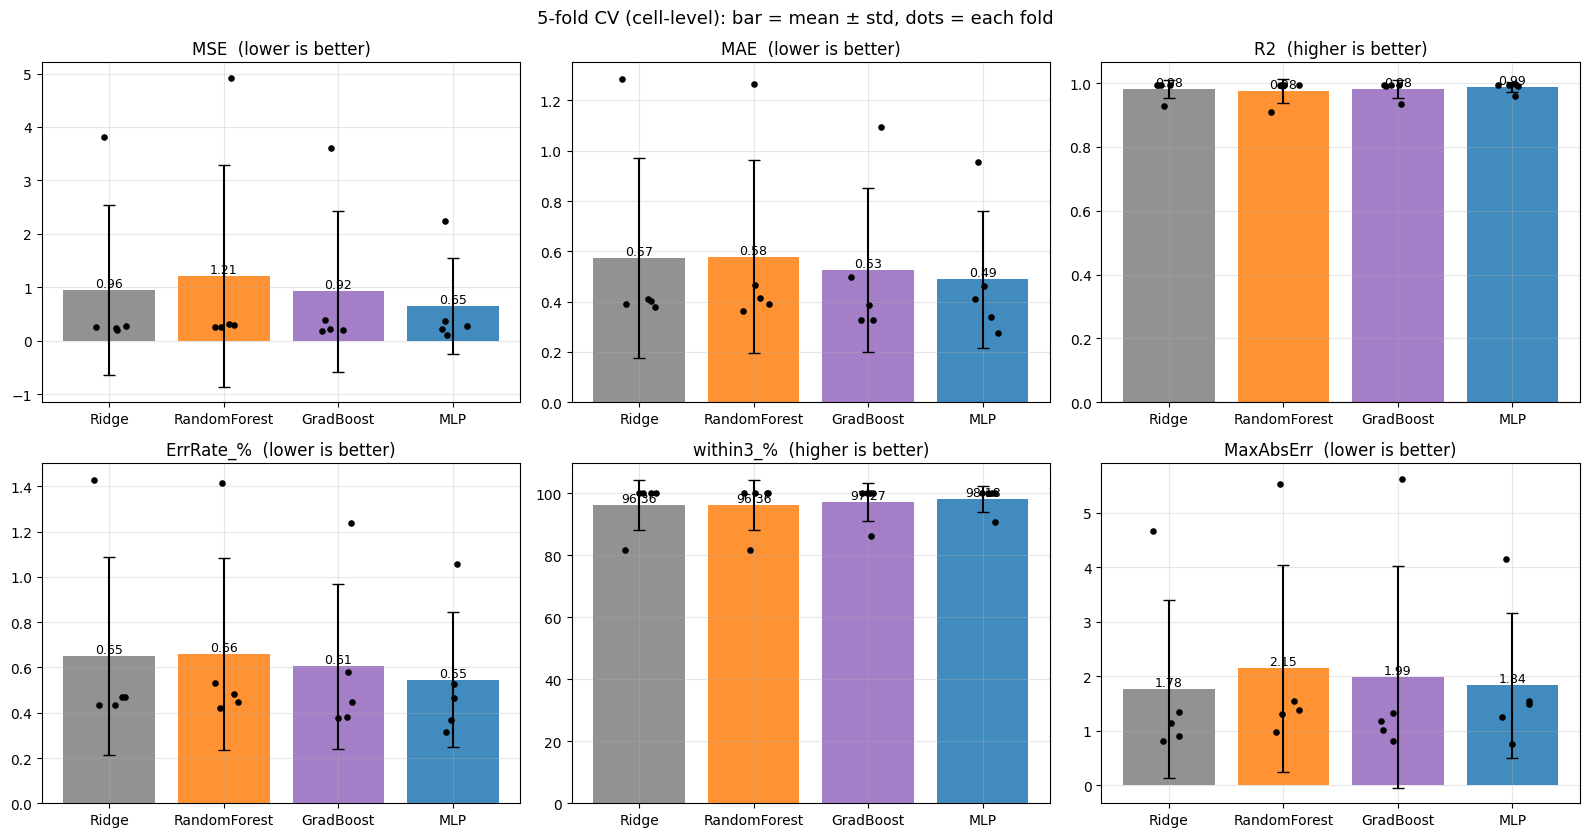

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
plot_metrics = ["MSE", "MAE", "R2", "ErrRate_%", "within3_%", "MaxAbsErr"]
for ax, mcol in zip(axes.flatten(), plot_metrics):
    means, stds = cv_mean[mcol], cv_std[mcol]
    ax.bar(MODEL_NAMES, means, yerr=stds, capsize=4, color=[MODEL_COLORS[m] for m in MODEL_NAMES], alpha=.85)
    # fold별 점 겹쳐 그리기 → 편차가 어디서 오는지 보임
    for i, m in enumerate(MODEL_NAMES):
        v = cv_df.loc[cv_df.model == m, mcol]
        ax.scatter(np.full(len(v), i) + np.random.uniform(-.15, .15, len(v)), v, color="k", s=14, zorder=3)
    for i, (mu) in enumerate(means): ax.text(i, mu, f"{mu:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{mcol}  ({'higher' if mcol in higher_better else 'lower'} is better)")
    if mcol == "R2": ax.axhline(0, color="red", lw=.8, ls="--")
fig.suptitle("5-fold CV (cell-level): bar = mean ± std, dots = each fold", fontsize=13)
plt.tight_layout(); plt.show()

## 5-3. Loss curve — MLP fold 5개 전부 (평가기준 3)

- 파란색 train, 주황색 val, 세로 점선 = early stopping이 고른 best epoch.
- train은 계속 내려가는데 val이 올라가면 **과적합**. 두 곡선 사이 간격이 클수록 일반화가 안 되는 것.
- y축 log scale. 값은 스케일된 타깃((y−90)/10)의 MSE → 실제 %² 로 보려면 ×100.


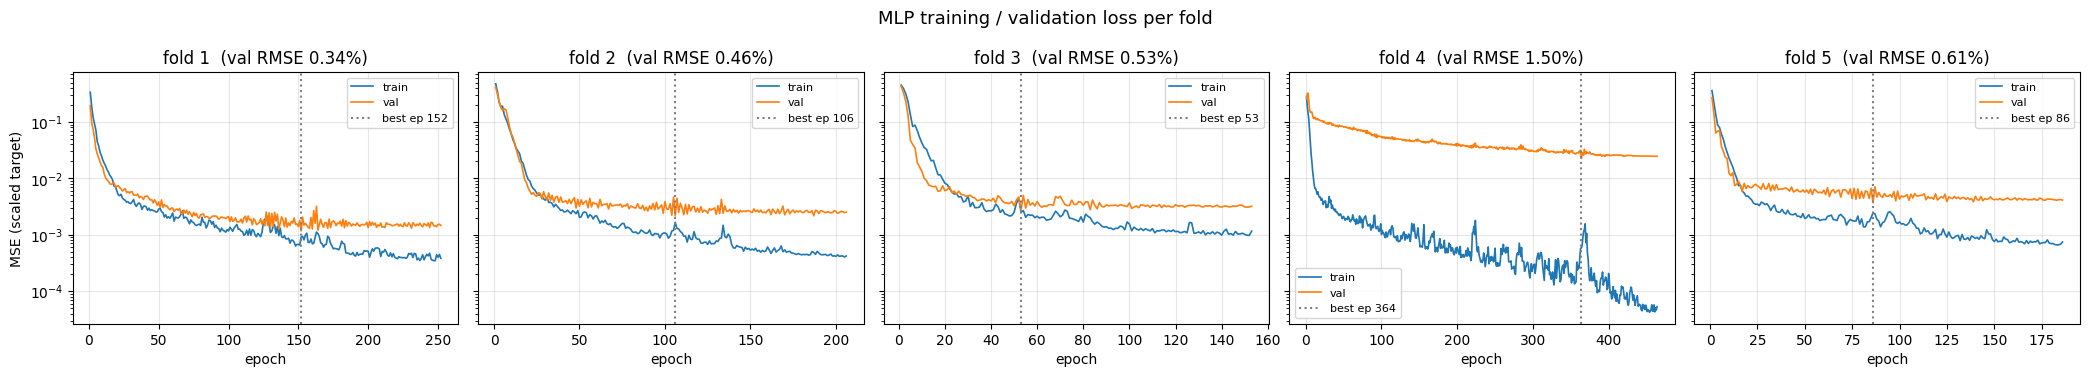

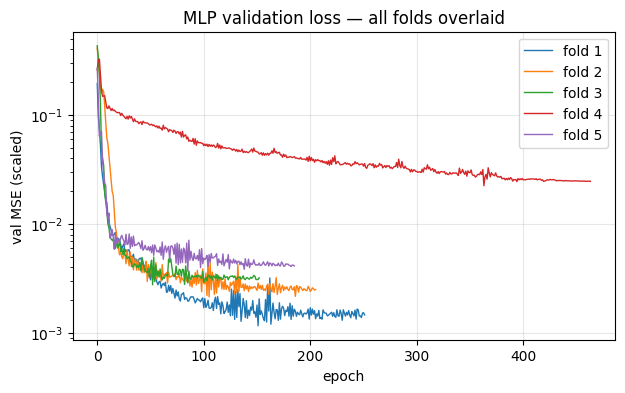

In [15]:
fig, axes = plt.subplots(1, CONFIG["n_folds"], figsize=(4.2 * CONFIG["n_folds"], 3.8), sharey=True)
for k, (ax, h) in enumerate(zip(axes, mlp_hists), 1):
    ep = np.arange(1, len(h["train"]) + 1)
    ax.plot(ep, h["train"], label="train", lw=1.2)
    ax.plot(ep, h["val"],   label="val",   lw=1.2)
    best = int(np.argmin(h["val"])) + 1
    ax.axvline(best, color="gray", ls=":", label=f"best ep {best}")
    ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_title(f"fold {k}  (val RMSE {cv_df[(cv_df.fold==k)&(cv_df.model=='MLP')].RMSE.iloc[0]:.2f}%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("MSE (scaled target)")
fig.suptitle("MLP training / validation loss per fold", fontsize=13); plt.tight_layout(); plt.show()

# fold 5개 val curve 겹쳐서 — 수렴 속도 비교
fig, ax = plt.subplots(figsize=(7, 4))
for k, h in enumerate(mlp_hists, 1): ax.plot(h["val"], label=f"fold {k}", lw=1)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("val MSE (scaled)"); ax.set_title("MLP validation loss — all folds overlaid"); ax.legend()
plt.show()

## 5-4. Predicted vs Actual — OOF (dev 19셀 전부, 모델 4개)

각 점은 CV에서 **자기 fold의 검증 셀이었을 때** 예측한 값 → 모델이 그 셀을 본 적 없는 상태의 예측.
대각선에 가까울수록 좋고, 색은 조건. 특정 조건(색)만 대각선에서 벗어나면 그 조건에 약한 모델.


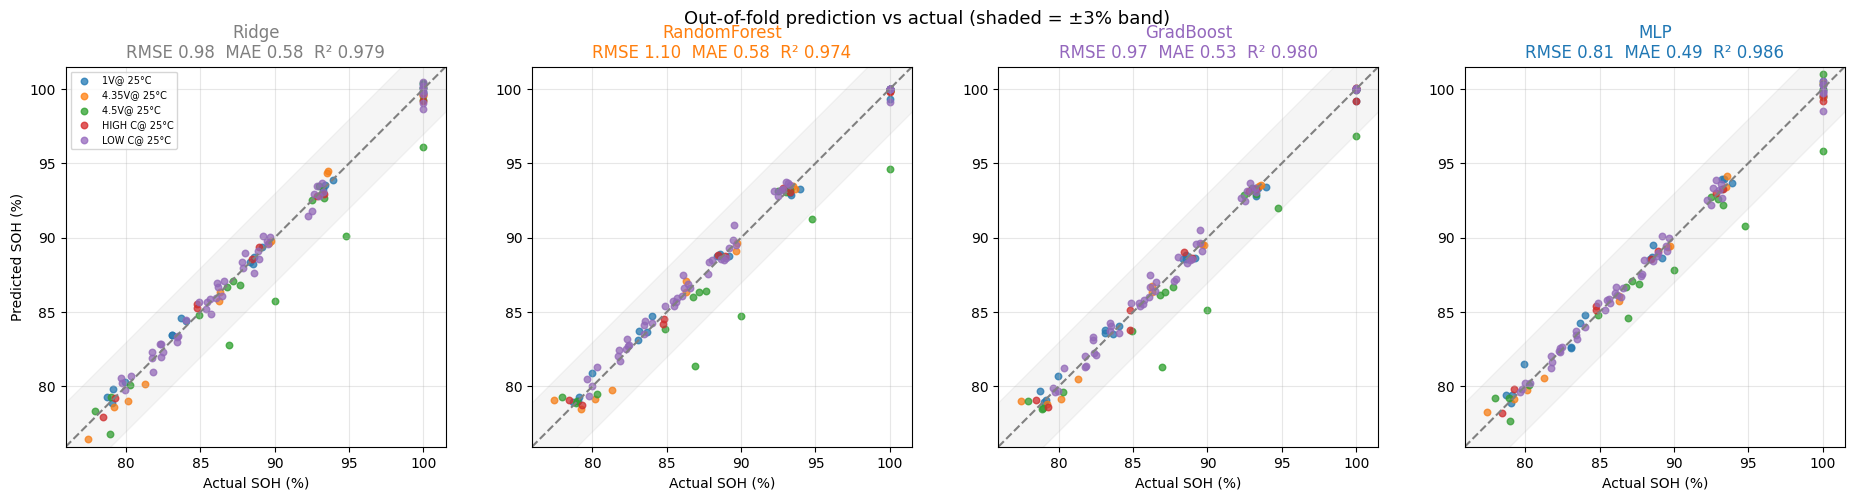

In [16]:
lo, hi = y_all.min() - 1.5, y_all.max() + 1.5
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
for ax, m in zip(axes, MODEL_NAMES):
    for c in conds:
        msk = (df_dev["cond"] == c).values
        ax.scatter(y_dev[msk], oof[m][msk], s=22, alpha=.75, color=cond_colors[c], label=c)
    ax.plot([lo, hi], [lo, hi], "--", color="gray")
    ax.fill_between([lo, hi], [lo - 3, hi - 3], [lo + 3, hi + 3], color="gray", alpha=.08)   # ±3% 밴드
    mt = metrics(y_dev, oof[m])
    ax.set_title(f"{m}\nRMSE {mt['RMSE']:.2f}  MAE {mt['MAE']:.2f}  R² {mt['R2']:.3f}", color=MODEL_COLORS[m])
    ax.set_xlabel("Actual SOH (%)"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
axes[0].set_ylabel("Predicted SOH (%)"); axes[0].legend(fontsize=7)
fig.suptitle("Out-of-fold prediction vs actual (shaded = ±3% band)", fontsize=13)
plt.tight_layout(); plt.show()

## 5-5. 잔차(Residual) 분석 — OOF

- (위) 잔차 vs 실제 SOH: 특정 SOH 구간에서 한쪽으로 치우치면 **편향**(예: 낮은 SOH를 과대예측). 0선 주위에 고르게 있어야 함.
- (아래) 잔차 히스토그램: 정규분포 모양 + 좁을수록 좋음.


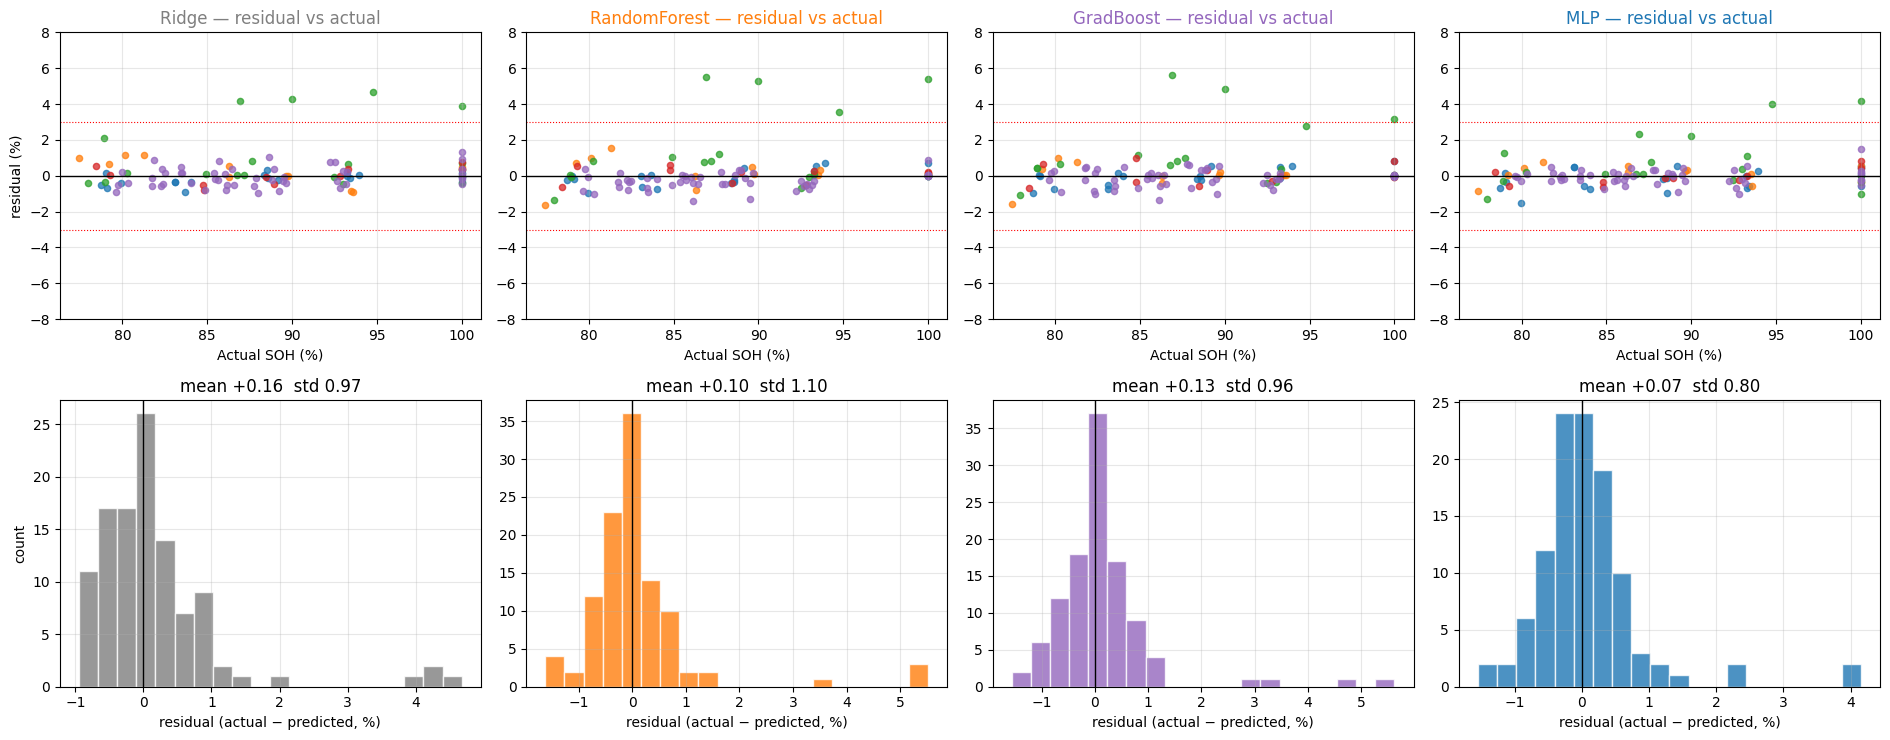

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
for j, m in enumerate(MODEL_NAMES):
    res = y_dev - oof[m]
    ax = axes[0, j]
    for c in conds:
        msk = (df_dev["cond"] == c).values
        ax.scatter(y_dev[msk], res[msk], s=20, alpha=.75, color=cond_colors[c])
    ax.axhline(0, color="k", lw=1); ax.axhline(3, color="red", ls=":", lw=.8); ax.axhline(-3, color="red", ls=":", lw=.8)
    ax.set_title(f"{m} — residual vs actual", color=MODEL_COLORS[m]); ax.set_xlabel("Actual SOH (%)")
    ax.set_ylim(-8, 8)
    ax = axes[1, j]
    ax.hist(res, bins=20, color=MODEL_COLORS[m], alpha=.8, edgecolor="white")
    ax.axvline(0, color="k", lw=1)
    ax.set_title(f"mean {res.mean():+.2f}  std {res.std():.2f}"); ax.set_xlabel("residual (actual − predicted, %)")
axes[0, 0].set_ylabel("residual (%)"); axes[1, 0].set_ylabel("count")
plt.tight_layout(); plt.show()

## 5-6. 조건별 · 셀별 오차

전체 평균이 좋아도 특정 조건에서 무너질 수 있다. 조건별 RMSE와 셀별 RMSE를 따로 본다.


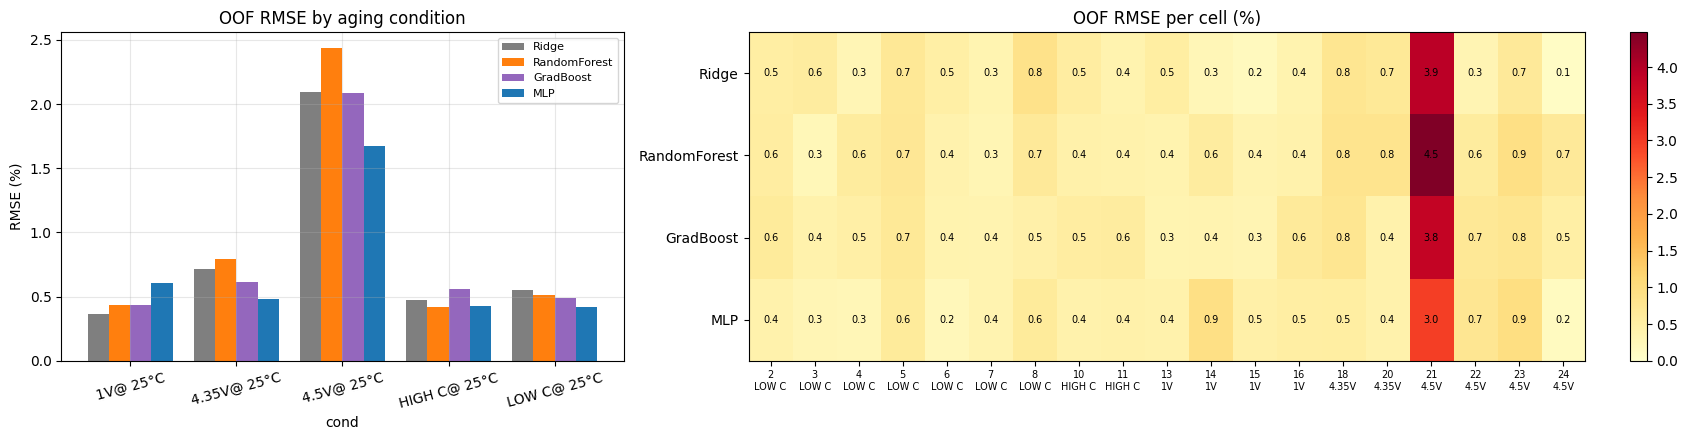

model         Ridge  RandomForest  GradBoost    MLP
cond                                               
1V@ 25°C      0.362         0.437      0.435  0.609
4.35V@ 25°C   0.718         0.795      0.610  0.478
4.5V@ 25°C    2.096         2.436      2.086  1.670
HIGH C@ 25°C  0.470         0.417      0.560  0.423
LOW C@ 25°C   0.551         0.515      0.492  0.418


In [18]:
# 조건별 RMSE (모델 × 조건)
rows = []
for m in MODEL_NAMES:
    for c in conds:
        msk = (df_dev["cond"] == c).values
        rows.append({"model": m, "cond": c, "RMSE": np.sqrt(np.mean((y_dev[msk] - oof[m][msk]) ** 2)), "n": int(msk.sum())})
cond_rmse = pd.DataFrame(rows).pivot(index="cond", columns="model", values="RMSE")[MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})
cond_rmse.plot.bar(ax=axes[0], color=[MODEL_COLORS[m] for m in MODEL_NAMES], width=.8)
axes[0].set_ylabel("RMSE (%)"); axes[0].set_title("OOF RMSE by aging condition"); axes[0].tick_params(axis="x", rotation=15); axes[0].legend(fontsize=8)

# 셀별 RMSE heatmap (셀 × 모델)
cell_rmse = pd.DataFrame({m: df_dev.assign(p=oof[m]).groupby(GROUP).apply(lambda d: np.sqrt(np.mean((d[TARGET] - d["p"]) ** 2)))
                          for m in MODEL_NAMES})
im = axes[1].imshow(cell_rmse.T.values, cmap="YlOrRd", aspect="auto", vmin=0)
axes[1].set_yticks(range(len(MODEL_NAMES))); axes[1].set_yticklabels(MODEL_NAMES)
axes[1].set_xticks(range(len(cell_rmse))); axes[1].set_xticklabels([f"{cid}\n{cell_cond[cid].split('@')[0]}" for cid in cell_rmse.index], fontsize=7)
for i in range(len(MODEL_NAMES)):
    for j in range(len(cell_rmse)):
        axes[1].text(j, i, f"{cell_rmse.T.values[i, j]:.1f}", ha="center", va="center", fontsize=7)
axes[1].grid(False); axes[1].set_title("OOF RMSE per cell (%)"); plt.colorbar(im, ax=axes[1], fraction=.02)
plt.tight_layout(); plt.show()
print(cond_rmse.round(3))

## 5-7. 셀별 열화 궤적 — 실제 vs 예측 (MLP, OOF)

셀 하나하나에 대해 RPT 순서대로 실제 SOH(검정)와 예측(파랑)을 겹쳐 본다. 모델이 "열화가 진행되는 방향"을 따라가는지, 아니면 평균값 근처만 찍는지가 보인다.


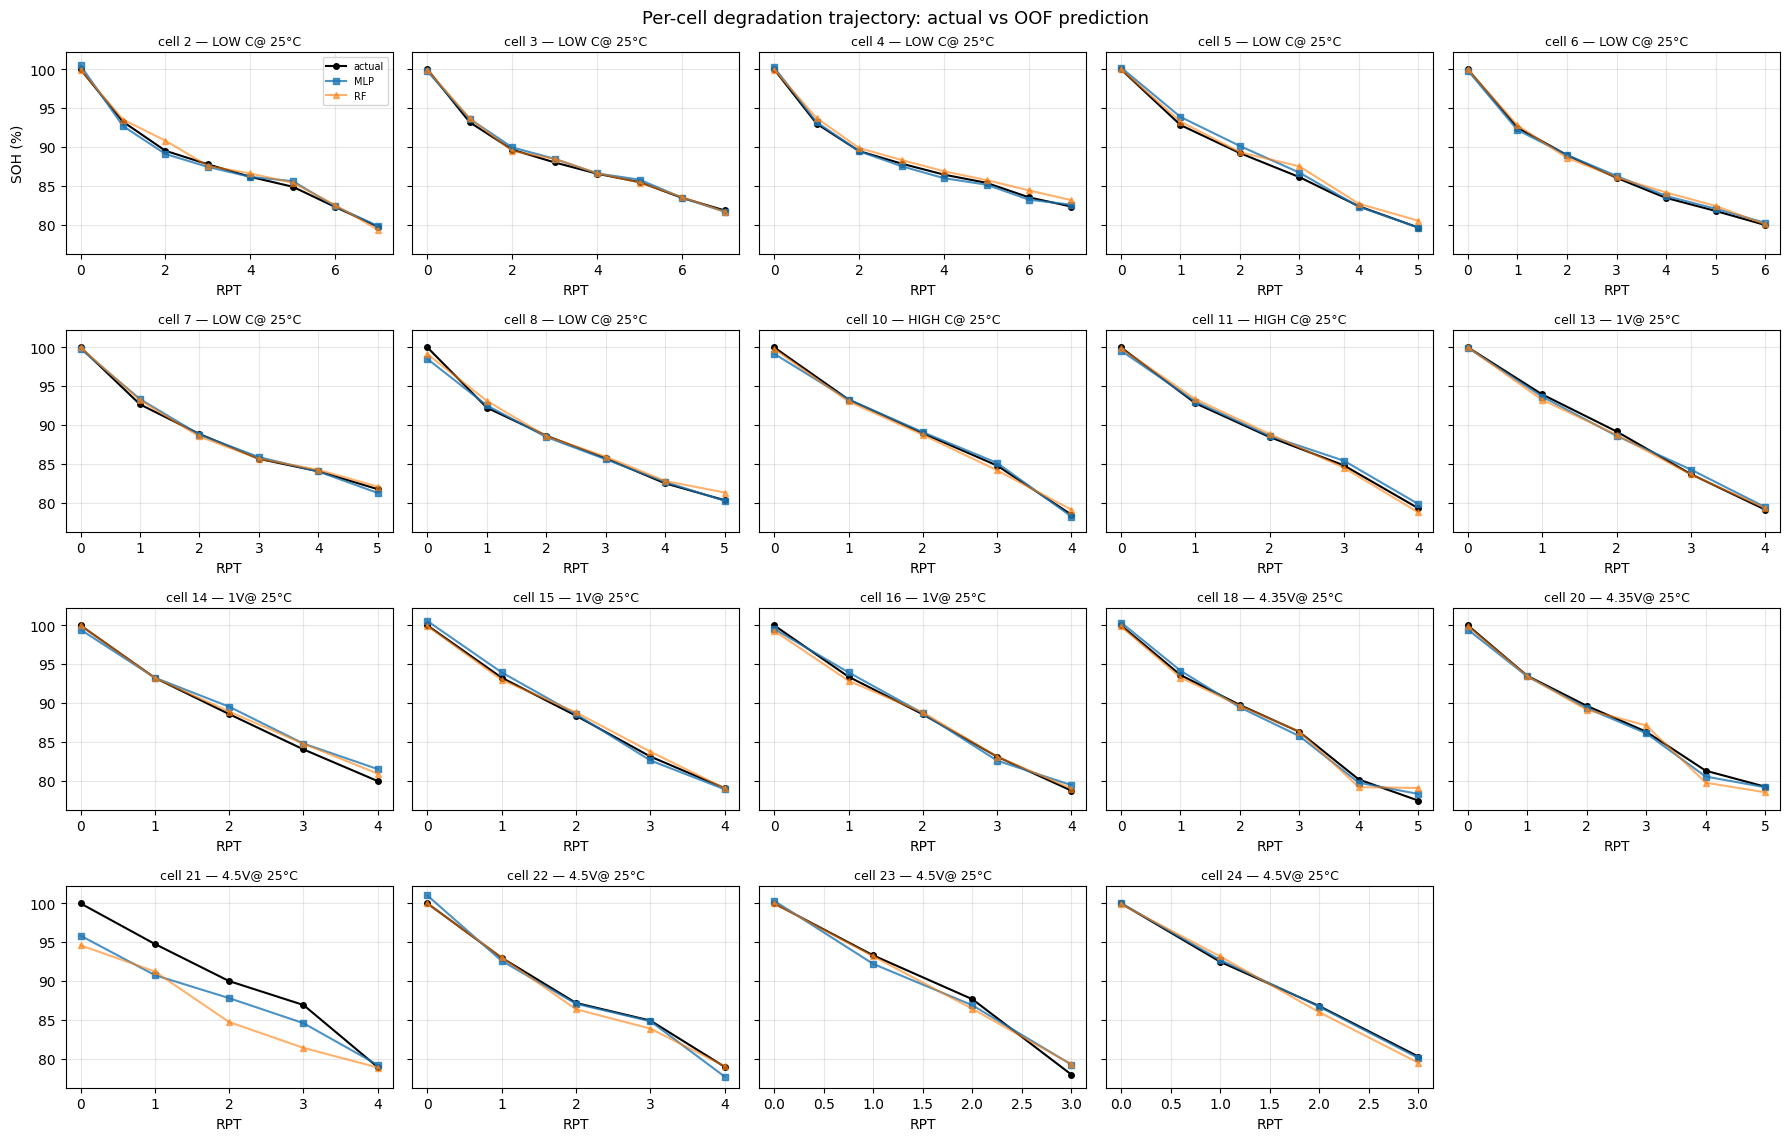

In [19]:
cells_dev = sorted(np.unique(g_dev))
n_cols = 5; n_rows = int(np.ceil(len(cells_dev) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 2.9 * n_rows), sharey=True)
axes = axes.flatten()
dd = df_dev.assign(MLP=oof["MLP"], RF=oof["RandomForest"])
for ax, cid in zip(axes, cells_dev):
    d = dd[dd[GROUP] == cid].sort_values("rpt_id")
    ax.plot(d["rpt_id"], d[TARGET], "k-o", ms=4, label="actual")
    ax.plot(d["rpt_id"], d["MLP"], "-s", ms=4, color=MODEL_COLORS["MLP"], alpha=.8, label="MLP")
    ax.plot(d["rpt_id"], d["RF"],  "-^", ms=4, color=MODEL_COLORS["RandomForest"], alpha=.6, label="RF")
    ax.set_title(f"cell {cid} — {d['cond'].iloc[0]}", fontsize=9); ax.set_xlabel("RPT")
for j in range(len(cells_dev), len(axes)): axes[j].axis("off")
axes[0].set_ylabel("SOH (%)"); axes[0].legend(fontsize=7)
fig.suptitle("Per-cell degradation trajectory: actual vs OOF prediction", fontsize=13)
plt.tight_layout(); plt.show()

# §6. 최종 학습 → Holdout Test (한 번만)

Dev 전체로 4개 모델을 다시 학습하고, 처음부터 떼어둔 **holdout 5셀**로 평가한다.
(MLP는 dev 안에서 20% 셀을 다시 떼어 early stopping용 val로 쓴다.)

CV 결과(§5)와 방향이 같으면 신뢰, 크게 다르면 holdout 셀 5개가 우연히 쉬웠거나/어려웠던 것.


In [20]:
final_models, test_pred, test_rows = {}, {}, []

# ---- sklearn ----
for name, mdl in make_sklearn_models(CONFIG["random_seed"]).items():
    t0 = time.perf_counter(); mdl.fit(X_dev, y_dev); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p = mdl.predict(X_test); t_inf = (time.perf_counter() - t0) / len(X_test)
    final_models[name] = mdl; test_pred[name] = p
    test_rows.append({"model": name, **metrics(y_test, p), "train_s": t_fit, "infer_us_per_row": t_inf * 1e6})

# ---- MLP: dev 안에서 val 셀 분리 후 학습 ----
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CONFIG["random_seed"] + 99)
tr2, va2 = next(gss2.split(X_dev, y_dev, groups=g_dev))
set_seed(CONFIG["random_seed"])
t0 = time.perf_counter()
mlp, mlp_scaler, mlp_hist, mlp_best_ep = train_mlp(X_dev[tr2], y_dev[tr2], X_dev[va2], y_dev[va2], verbose=True)
t_fit = time.perf_counter() - t0
t0 = time.perf_counter(); p = mlp_predict(mlp, mlp_scaler, X_test); t_inf = (time.perf_counter() - t0) / len(X_test)
final_models["MLP"] = (mlp, mlp_scaler); test_pred["MLP"] = p
test_rows.append({"model": "MLP", **metrics(y_test, p), "train_s": t_fit, "infer_us_per_row": t_inf * 1e6})
torch.save(mlp.state_dict(), "best_mlp_model.pth")

test_df = pd.DataFrame(test_rows).set_index("model").reindex(MODEL_NAMES)
print(f"\n=== Holdout Test ({len(np.unique(g_test))} cells, {len(y_test)} rows) ===")
display(test_df.round(3))
print("\n(참고) CV 평균 RMSE:", cv_mean["RMSE"].round(3).to_dict())

  ep  100  train 0.0016  val 0.0565  lr 3.0e-03
  ep  200  train 0.0005  val 0.0482  lr 3.0e-03

=== Holdout Test (5 cells, 32 rows) ===


,MSE,RMSE,MAE,R2,ErrRate_%,within3_%,MaxAbsErr,train_s,infer_us_per_row
model,,,,,,,,,
Ridge,0.150,0.387,0.341,0.997,0.389,100.0,0.653,0.005,76.360
RandomForest,0.112,0.335,0.235,0.997,0.268,100.0,1.195,0.478,1742.367
GradBoost,0.126,0.356,0.250,0.997,0.289,100.0,0.892,0.410,27.086
MLP,0.157,0.397,0.325,0.996,0.371,100.0,0.877,2.546,26.424



(참고) CV 평균 RMSE: {'Ridge': 0.786, 'RandomForest': 0.871, 'GradBoost': 0.776, 'MLP': 0.688}


## 6-1. 최종 MLP loss curve (train / val / learning-rate)

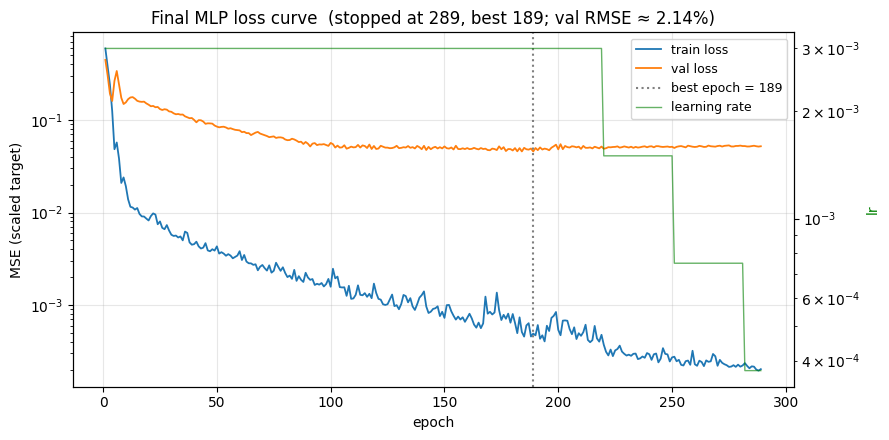

In [21]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ep = np.arange(1, len(mlp_hist["train"]) + 1)
ax1.plot(ep, mlp_hist["train"], label="train loss", lw=1.3)
ax1.plot(ep, mlp_hist["val"],   label="val loss",   lw=1.3)
ax1.axvline(mlp_best_ep, color="gray", ls=":", label=f"best epoch = {mlp_best_ep}")
ax1.set_yscale("log"); ax1.set_xlabel("epoch"); ax1.set_ylabel("MSE (scaled target)")
ax2 = ax1.twinx(); ax2.plot(ep, mlp_hist["lr"], color="green", lw=1, alpha=.6, label="learning rate"); ax2.set_yscale("log"); ax2.set_ylabel("lr", color="green"); ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, fontsize=9)
ax1.set_title(f"Final MLP loss curve  (stopped at {len(ep)}, best {mlp_best_ep}; val RMSE ≈ {np.sqrt(min(mlp_hist['val']))*Y_SCALE:.2f}%)")
plt.tight_layout(); plt.show()

## 6-2. Holdout — Predicted vs Actual (4모델) + 셀별 궤적

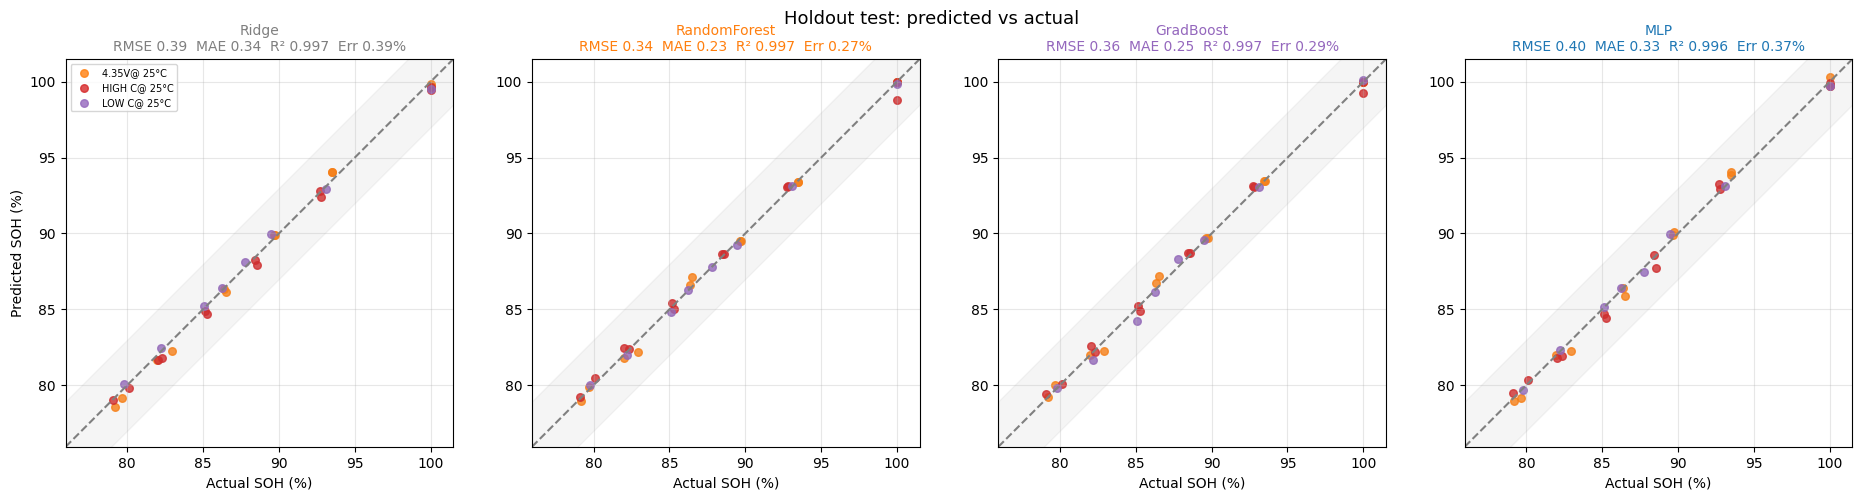

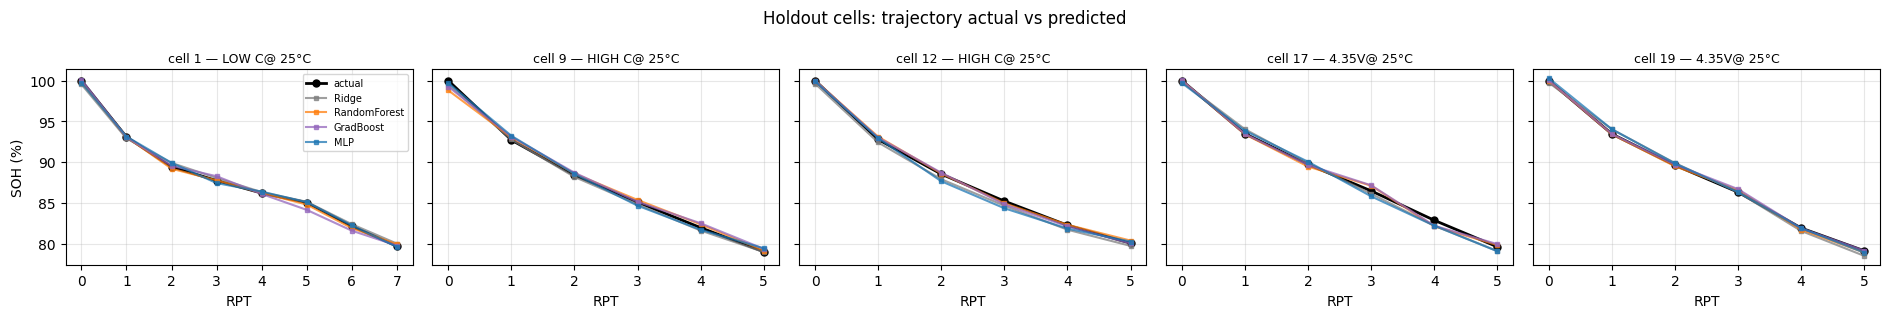

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
for ax, m in zip(axes, MODEL_NAMES):
    for c in conds:
        msk = (df_test["cond"] == c).values
        if msk.any(): ax.scatter(y_test[msk], test_pred[m][msk], s=30, alpha=.8, color=cond_colors[c], label=c)
    ax.plot([lo, hi], [lo, hi], "--", color="gray")
    ax.fill_between([lo, hi], [lo - 3, hi - 3], [lo + 3, hi + 3], color="gray", alpha=.08)
    mt = test_df.loc[m]
    ax.set_title(f"{m}\nRMSE {mt['RMSE']:.2f}  MAE {mt['MAE']:.2f}  R² {mt['R2']:.3f}  Err {mt['ErrRate_%']:.2f}%", color=MODEL_COLORS[m], fontsize=10)
    ax.set_xlabel("Actual SOH (%)"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
axes[0].set_ylabel("Predicted SOH (%)"); axes[0].legend(fontsize=7)
fig.suptitle("Holdout test: predicted vs actual", fontsize=13); plt.tight_layout(); plt.show()

# 셀별 궤적 (holdout 5셀)
cells_test = sorted(np.unique(g_test))
fig, axes = plt.subplots(1, len(cells_test), figsize=(3.8 * len(cells_test), 3.2), sharey=True)
dt = df_test.copy()
for m in MODEL_NAMES: dt[m] = test_pred[m]
for ax, cid in zip(np.atleast_1d(axes), cells_test):
    d = dt[dt[GROUP] == cid].sort_values("rpt_id")
    ax.plot(d["rpt_id"], d[TARGET], "k-o", ms=5, lw=2, label="actual")
    for m in MODEL_NAMES: ax.plot(d["rpt_id"], d[m], "-", ms=3, marker="s", color=MODEL_COLORS[m], alpha=.75, label=m)
    ax.set_title(f"cell {cid} — {d['cond'].iloc[0]}", fontsize=9); ax.set_xlabel("RPT")
np.atleast_1d(axes)[0].set_ylabel("SOH (%)"); np.atleast_1d(axes)[0].legend(fontsize=7)
fig.suptitle("Holdout cells: trajectory actual vs predicted", fontsize=12); plt.tight_layout(); plt.show()

## 6-3. 오차 vs SOH 구간 — 어느 SOH 대역에서 틀리나

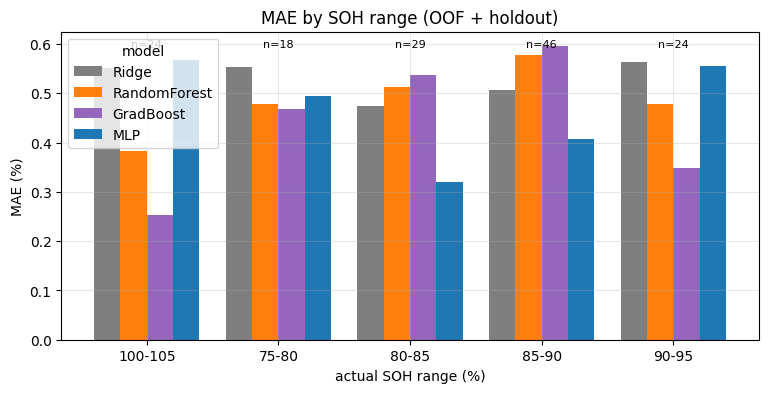

In [23]:
# holdout + OOF 합쳐서 SOH 구간별 MAE (구간: 5% 단위)
bins = np.arange(75, 101, 5)
rows = []
for m in MODEL_NAMES:
    y_c = np.concatenate([y_dev, y_test]); p_c = np.concatenate([oof[m], test_pred[m]])
    b = np.digitize(y_c, bins)
    for bi in np.unique(b):
        msk = b == bi
        rows.append({"model": m, "bin": f"{bins[bi-1]}-{bins[bi-1]+5}", "MAE": np.mean(np.abs(y_c[msk] - p_c[msk])), "n": int(msk.sum())})
bin_df = pd.DataFrame(rows).pivot(index="bin", columns="model", values="MAE")[MODEL_NAMES]
ax = bin_df.plot.bar(figsize=(9, 4), color=[MODEL_COLORS[m] for m in MODEL_NAMES], width=.8)
ax.set_ylabel("MAE (%)"); ax.set_xlabel("actual SOH range (%)"); ax.set_title("MAE by SOH range (OOF + holdout)")
ax.tick_params(axis="x", rotation=0)
n_per_bin = pd.DataFrame(rows).groupby("bin")["n"].first()
for i, b in enumerate(bin_df.index): ax.text(i, ax.get_ylim()[1] * .95, f"n={n_per_bin[b]}", ha="center", fontsize=8)
plt.show()

# §7. 학습 데이터 양 vs 성능 (Learning curve)

"데이터가 더 있으면 나아질까?"에 대한 답. dev 셀의 30/50/70/100%만 써서 학습 → 같은 검증 셀로 평가.
- 곡선이 아직 내려가는 중이면 데이터 추가(다른 온도 조건, 60셀 전체)가 효과 있음.
- 평평하면 feature/모델 쪽 문제.


In [ ]:
if RUN_LEARNING_CURVE:
    fracs = [0.3, 0.5, 0.7, 1.0]
    lc_rows = []
    for k, (tr, va) in enumerate(FOLDS, 1):
        tr_cells = np.unique(g_dev[tr])
        for frac in fracs:
            for rep in range(3):                                   # 셀 서브샘플 3번 반복
                rng = np.random.RandomState(100 * k + rep)
                keep = rng.choice(tr_cells, size=max(3, int(round(frac * len(tr_cells)))), replace=False)
                sub = tr[np.isin(g_dev[tr], keep)]
                # MLP
                set_seed(100 * k + rep)
                mdl, sc, _, _ = train_mlp(X_dev[sub], y_dev[sub], X_dev[va], y_dev[va])
                lc_rows.append({"fold": k, "frac": frac, "rep": rep, "model": "MLP", "n_cells": len(keep),
                                "RMSE": metrics(y_dev[va], mlp_predict(mdl, sc, X_dev[va]))["RMSE"]})
                # RF
                rf = RandomForestRegressor(n_estimators=200, random_state=rep, n_jobs=-1).fit(X_dev[sub], y_dev[sub])
                lc_rows.append({"fold": k, "frac": frac, "rep": rep, "model": "RandomForest", "n_cells": len(keep),
                                "RMSE": metrics(y_dev[va], rf.predict(X_dev[va]))["RMSE"]})
        print(f"fold {k} done")
    lc = pd.DataFrame(lc_rows)
    agg = lc.groupby(["model", "frac"]).agg(RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"), n_cells=("n_cells", "mean")).reset_index()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for m in ["MLP", "RandomForest"]:
        a = agg[agg.model == m]
        ax.errorbar(a["n_cells"], a["RMSE_mean"], yerr=a["RMSE_std"], marker="o", capsize=4, label=m, color=MODEL_COLORS[m])
    ax.set_xlabel("number of training cells"); ax.set_ylabel("CV RMSE (%)"); ax.set_title("Learning curve: training cells vs RMSE")
    ax.legend(); plt.show()
    display(agg.round(3))
else:
    print("RUN_LEARNING_CURVE = False → 건너뜀")

# §8. Feature Importance (평가기준 2·3)

feature 25개를 편견 없이 넣었으니, **여기서 나온 결과로 나중에 뺄 것을 정한다.** 방법 4가지를 나란히 놓고 본다. 한 방법에서만 높은 feature는 의심.

| 방법 | 대상 | 뜻 |
|---|---|---|
| RF impurity | RandomForest | 트리 분할에서 불순도를 얼마나 줄였나. **상관 높은 feature끼리 점수를 나눠 가짐** → 개별 값 과소평가 가능 |
| Permutation (MLP) | MLP, CV fold별 | 해당 feature 열을 섞었을 때 val RMSE가 얼마나 나빠지나. 모델 무관, 가장 신뢰 |
| Gradient saliency (MLP) | 최종 MLP | 평균 \|∂SOH/∂x_norm\|. 모델이 입력 변화에 얼마나 민감한가 |
| Ridge \|coef\| | Ridge | 표준화된 입력의 선형 계수 크기. 부호가 물리적 방향과 맞는지 확인용 |
| (옵션) Drop-one | MLP CV | feature 하나 빼고 CV 재학습 → RMSE 변화. 가장 정직하지만 느림 |

**주의: `ccct`(CC 충전 시간)는 충전 용량 ≈ SOH 라벨과 거의 같은 양이라 라벨 누설 성격이 있다.** 중요도가 높게 나오는 게 당연하고, 이걸 보고 "좋은 feature"라고 결론내면 안 됨. 시연 때 보드에서 측정 가능한지와 별개로, 평가 시 이 점을 같이 적어둘 것.


In [ ]:
# ── (1) RF impurity importance (fold 5개 평균) ────────────────────────────────
imp_rf = pd.Series(np.mean(rf_importances, axis=0), index=FEATURES)

# ── (2) Permutation importance on MLP (CV fold별 val set에서, 20회 반복) ───────
def permutation_importance_mlp(model, scaler, X, y, n_repeats=20, seed=0):
    rng = np.random.RandomState(seed)
    base = metrics(y, mlp_predict(model, scaler, X))["RMSE"]
    out = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            Xp = X.copy(); Xp[:, j] = rng.permutation(Xp[:, j])   # j번째 열만 섞어서 정보 파괴
            deltas.append(metrics(y, mlp_predict(model, scaler, Xp))["RMSE"] - base)
        out[j] = np.mean(deltas)
    return out                                                    # RMSE 증가량 (%). 클수록 중요

perm_folds = []
for k, (model, scaler, va) in enumerate(mlp_fold_models):
    perm_folds.append(permutation_importance_mlp(model, scaler, X_dev[va], y_dev[va], seed=k))
perm_folds = np.array(perm_folds)
imp_perm = pd.Series(perm_folds.mean(axis=0), index=FEATURES)
imp_perm_std = pd.Series(perm_folds.std(axis=0), index=FEATURES)

# ── (3) Gradient saliency (최종 MLP, dev 전체 입력에 대해 평균 |dy/dx|) ─────────
Xn = torch.tensor(mlp_scaler.transform(X_dev), dtype=torch.float32, requires_grad=True)
mlp.eval(); out = mlp(Xn).sum(); out.backward()
imp_grad = pd.Series(Xn.grad.abs().mean(dim=0).numpy() * Y_SCALE, index=FEATURES)   # 단위: %SOH per 1σ 입력 변화
signed_grad = pd.Series(Xn.grad.mean(dim=0).numpy() * Y_SCALE, index=FEATURES)      # 부호 포함 (방향)

# ── (4) Ridge 계수 (표준화 입력이라 크기 비교 가능) ─────────────────────────────
ridge_coef = pd.Series(final_models["Ridge"][-1].coef_, index=FEATURES)

imp = pd.DataFrame({
    "spearman_rho":  pd.Series(spearman),
    "RF_impurity":   imp_rf,
    "MLP_perm_dRMSE": imp_perm,
    "MLP_grad_abs":  imp_grad,
    "Ridge_coef":    ridge_coef,
}).reindex(FEATURES)
imp["group"] = [feat_group(f) for f in FEATURES]

# 방법별 순위 (1 = 가장 중요) + 평균 순위
for c in ["RF_impurity", "MLP_perm_dRMSE", "MLP_grad_abs"]:
    imp[f"rank_{c}"] = imp[c].rank(ascending=False).astype(int)
imp["rank_Ridge_coef"] = imp["Ridge_coef"].abs().rank(ascending=False).astype(int)
imp["avg_rank"] = imp[[c for c in imp.columns if c.startswith("rank_")]].mean(axis=1)
imp = imp.sort_values("avg_rank")
display(imp.round(4))

## 8-1. Feature importance — 4가지 방법 나란히

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(21, 0.33 * N_FEAT + 1.5), sharey=True)
order = imp.index[::-1]                                      # 평균 순위 좋은 게 위로
cols = [("RF_impurity", "RF impurity importance"),
        ("MLP_perm_dRMSE", "MLP permutation: ΔRMSE (%)"),
        ("MLP_grad_abs", "MLP mean |∂SOH/∂x| (%/σ)"),
        ("Ridge_coef", "Ridge coef (standardized)")]
for ax, (c, title) in zip(axes, cols):
    vals = imp.loc[order, c]
    ax.barh(order, vals, color=[GROUP_COLOR[feat_group(f)] for f in order],
            xerr=imp_perm_std[order] if c == "MLP_perm_dRMSE" else None, capsize=2)
    ax.axvline(0, color="k", lw=.8); ax.set_title(title)
for lbl in axes[0].get_yticklabels(): lbl.set_color(GROUP_COLOR[feat_group(lbl.get_text())])
fig.suptitle("Feature importance by 4 methods (rows sorted by average rank; blue=dQ, red=DCIR, green=Time)", fontsize=13)
plt.tight_layout(); plt.show()

## 8-2. 순위 비교 heatmap + 계열별 합산

- (왼쪽) 방법 × feature 순위. 색이 진할수록(순위 낮을수록) 중요. 가로로 일관되게 진하면 확실한 feature.
- (오른쪽) 계열(dQ / DCIR / Time)별 permutation importance 합 → "어느 측정이 중요한가"의 큰 그림.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 0.33 * N_FEAT + 1.5), gridspec_kw={"width_ratios": [1.2, 1]})
rank_cols = ["rank_RF_impurity", "rank_MLP_perm_dRMSE", "rank_MLP_grad_abs", "rank_Ridge_coef"]
R = imp[rank_cols]
im = axes[0].imshow(R.values, cmap="YlGn_r", aspect="auto", vmin=1, vmax=N_FEAT)
axes[0].set_yticks(range(N_FEAT)); axes[0].set_yticklabels(R.index)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(["RF", "Perm", "Grad", "Ridge"])
for i in range(N_FEAT):
    for j in range(4): axes[0].text(j, i, int(R.values[i, j]), ha="center", va="center", fontsize=8)
for lbl in axes[0].get_yticklabels(): lbl.set_color(GROUP_COLOR[feat_group(lbl.get_text())])
axes[0].grid(False); axes[0].set_title("Importance rank per method (1 = most important)")

grp = imp.groupby("group")[["RF_impurity", "MLP_perm_dRMSE"]].sum()
grp["MLP_perm_dRMSE_per_feat"] = imp.groupby("group")["MLP_perm_dRMSE"].mean()
grp[["RF_impurity", "MLP_perm_dRMSE"]].plot.bar(ax=axes[1], color=["#ff7f0e", "#1f77b4"])
axes[1].set_title("Importance summed by feature group"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
display(grp.round(4))

## 8-3. MLP 1층 weight heatmap — 모델이 어떤 feature를 실제로 쓰는지

`Linear(N→16)`의 weight 행렬 (16 hidden × N feature). 열 전체가 옅으면 그 feature는 사실상 무시되고 있음.
아래 막대 = 열별 \|w\| 합 (Ridge 계수와 비슷한 역할).


In [ ]:
W1 = mlp.network[0].weight.detach().numpy()          # (16, N)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
vmax = np.abs(W1).max()
im = axes[0].imshow(W1, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
axes[0].set_yticks(range(16)); axes[0].set_ylabel("hidden unit"); axes[0].grid(False)
axes[0].set_title("First-layer weights of final MLP (16 hidden × N features)")
plt.colorbar(im, ax=axes[0], fraction=.02)
colsum = np.abs(W1).sum(axis=0)
axes[1].bar(range(N_FEAT), colsum, color=[GROUP_COLOR[feat_group(f)] for f in FEATURES])
axes[1].set_xticks(range(N_FEAT)); axes[1].set_xticklabels(FEATURES, rotation=90, fontsize=8)
axes[1].set_ylabel("Σ|w|")
plt.tight_layout(); plt.show()

## 8-4. 방향(부호) 일관성 체크 — 이해도

물리적으로 SOH가 떨어지면: 내부저항(DCIR)↑, 충전시간(ccct)↓, CV 시간↑ 등. 모델이 배운 방향(Ridge 계수, MLP gradient 부호)이 데이터의 Spearman 부호와 맞는지 확인. **세 개가 다 다르면** 그 feature는 다른 feature와 얽혀 모델이 상쇄용으로 쓰고 있다는 뜻 → 설명 어려움 → 제외 후보.


In [ ]:
sign_df = pd.DataFrame({
    "spearman": np.sign(imp["spearman_rho"]),
    "Ridge":    np.sign(imp["Ridge_coef"]),
    "MLP_grad": np.sign(signed_grad.reindex(imp.index)),
}).astype(int)
sign_df["consistent"] = (sign_df.nunique(axis=1) == 1)
fig, ax = plt.subplots(figsize=(6, 0.3 * N_FEAT + 1))
im = ax.imshow(sign_df[["spearman", "Ridge", "MLP_grad"]].values, cmap="bwr", vmin=-1, vmax=1, aspect="auto")
ax.set_yticks(range(N_FEAT)); ax.set_yticklabels(sign_df.index); ax.set_xticks(range(3)); ax.set_xticklabels(["Spearman", "Ridge", "MLP grad"])
for i, f in enumerate(sign_df.index):
    ax.text(3.1, i, "OK" if sign_df.loc[f, "consistent"] else "MIXED", va="center", fontsize=8,
            color="green" if sign_df.loc[f, "consistent"] else "red")
for lbl in ax.get_yticklabels(): lbl.set_color(GROUP_COLOR[feat_group(lbl.get_text())])
ax.set_xlim(-.5, 3.8); ax.grid(False); ax.set_title("Sign of relationship with SOH (red=+, blue=−)")
plt.tight_layout(); plt.show()
print("부호 불일치 feature:", list(sign_df.index[~sign_df.consistent]))

## 8-5. (옵션) Drop-one — feature 하나씩 빼고 CV 재학습

`RUN_DROP_ONE = True`로 켜면 실행. 25 × 5 fold = 125번 MLP 학습 (약 10분).
막대가 **양수** = 그 feature를 빼니 RMSE가 올라감 (필요한 feature). **음수** = 빼니 오히려 좋아짐 (제외 후보, 노이즈/과적합 유발).


In [ ]:
def cv_rmse_mlp(feat_idx, seeds=(0,)):
    # 주어진 feature 열 인덱스만 써서 5-fold MLP CV RMSE 평균
    scores = []
    for s in seeds:
        for k, (tr, va) in enumerate(FOLDS, 1):
            set_seed(1000 * s + k)
            mdl, sc, _, _ = train_mlp(X_dev[tr][:, feat_idx], y_dev[tr], X_dev[va][:, feat_idx], y_dev[va])
            scores.append(metrics(y_dev[va], mlp_predict(mdl, sc, X_dev[va][:, feat_idx]))["RMSE"])
    return float(np.mean(scores))

if RUN_DROP_ONE:
    base_cv = cv_rmse_mlp(list(range(N_FEAT)))
    print(f"baseline (all {N_FEAT}) CV RMSE = {base_cv:.3f}")
    drop = {}
    for j, f in enumerate(FEATURES):
        idx = [i for i in range(N_FEAT) if i != j]
        drop[f] = cv_rmse_mlp(idx) - base_cv
        print(f"  drop {f:14s} → ΔRMSE {drop[f]:+.3f}")
    drop = pd.Series(drop).sort_values()
    fig, ax = plt.subplots(figsize=(8, 0.32 * N_FEAT + 1))
    ax.barh(drop.index, drop.values, color=["#d62728" if v > 0 else "#2ca02c" for v in drop.values])
    ax.axvline(0, color="k"); ax.set_xlabel("ΔRMSE when dropped (%)  [>0: needed, <0: remove candidate]")
    ax.set_title(f"Drop-one feature analysis (MLP, baseline {base_cv:.3f}%)"); plt.tight_layout(); plt.show()
    imp["drop_one_dRMSE"] = drop.reindex(imp.index)
else:
    print("RUN_DROP_ONE = False → 건너뜀 (켜면 약 10분)")

# §9. 모델 속도 (평가기준 4)

- **학습 시간**: CV fold 평균 (CPU). MLP는 early stopping 시점에 따라 달라짐.
- **추론 시간/샘플**: 1행씩 넣어서 1000번 반복 측정 (실제 보드 시나리오 = 배터리 1개씩 판정).
- **연산량(MAC)**: FPGA에서 실제로 의미 있는 건 이것. MLP = 16N + 128 + 8 곱셈-누산.

PC 추론 시간은 sklearn/torch 오버헤드가 커서 절대값보다 **상대 비교**만 의미 있음.


In [ ]:
# 단일 샘플 추론 시간 (1000회 반복)
def time_single(fn, x_row, n=1000):
    fn(x_row)                                  # warm-up
    t0 = time.perf_counter()
    for _ in range(n): fn(x_row)
    return (time.perf_counter() - t0) / n * 1e6   # µs

x1 = X_test[:1]
single_us = {
    "Ridge":        time_single(lambda x: final_models["Ridge"].predict(x), x1),
    "RandomForest": time_single(lambda x: final_models["RandomForest"].predict(x), x1, n=200),
    "GradBoost":    time_single(lambda x: final_models["GradBoost"].predict(x), x1, n=200),
    "MLP":          time_single(lambda x: mlp_predict(mlp, mlp_scaler, x), x1),
}
# 순수 MLP 행렬곱만 (numpy) — 프레임워크 오버헤드 제거 버전. FPGA 연산량 감 잡기용
Ws = [(mlp.network[i].weight.detach().numpy(), mlp.network[i].bias.detach().numpy()) for i in (0, 2, 4)]
mu, sd = mlp_scaler.mean_, mlp_scaler.scale_
def mlp_numpy(x):
    h = (x - mu) / sd
    h = np.maximum(h @ Ws[0][0].T + Ws[0][1], 0)
    h = np.maximum(h @ Ws[1][0].T + Ws[1][1], 0)
    return (h @ Ws[2][0].T + Ws[2][1]) * Y_SCALE + Y_OFFSET
assert np.allclose(mlp_numpy(X_test[:5]).flatten(), test_pred["MLP"][:5], atol=1e-3)   # torch와 같은 답인지 확인
single_us["MLP (numpy only)"] = time_single(mlp_numpy, x1.astype(np.float64))

speed = pd.DataFrame({
    "train_s (CV mean)":   cv_mean["train_s"].reindex(MODEL_NAMES),
    "infer_us/row (batch)": cv_mean["infer_us_per_row"].reindex(MODEL_NAMES),
    "infer_us (single)":   pd.Series(single_us).reindex(MODEL_NAMES),
    "MACs/inference":      [N_FEAT, np.nan, np.nan, 16 * N_FEAT + 16 * 8 + 8],
})
speed.loc["MLP (numpy only)", "infer_us (single)"] = single_us["MLP (numpy only)"]
display(speed.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(MODEL_NAMES, speed.loc[MODEL_NAMES, "train_s (CV mean)"], color=[MODEL_COLORS[m] for m in MODEL_NAMES])
axes[0].set_yscale("log"); axes[0].set_ylabel("seconds (log)"); axes[0].set_title("Training time per fold (CPU)")
for i, m in enumerate(MODEL_NAMES): axes[0].text(i, speed.loc[m, "train_s (CV mean)"], f"{speed.loc[m, 'train_s (CV mean)']:.2f}s", ha="center", va="bottom", fontsize=9)
names = MODEL_NAMES + ["MLP (numpy only)"]
axes[1].bar(names, [single_us[m] for m in names], color=[MODEL_COLORS.get(m, "#17becf") for m in names])
axes[1].set_yscale("log"); axes[1].set_ylabel("µs (log)"); axes[1].set_title("Single-sample inference time (CPU)")
for i, m in enumerate(names): axes[1].text(i, single_us[m], f"{single_us[m]:.0f}", ha="center", va="bottom", fontsize=9)
axes[1].tick_params(axis="x", rotation=10)
plt.tight_layout(); plt.show()

# §10. 종합 스코어카드 — 4가지 기준 한 장

팀장님 기준 4개를 한 표/한 그림으로. 정확도는 CV 평균(holdout은 5셀이라 참고용), 간편성은 파라미터 수와 FPGA 구현성, 속도는 추론 시간.
레이더 차트는 각 축을 0~1로 정규화(1 = 4모델 중 최고).


In [ ]:
score = pd.DataFrame(index=MODEL_NAMES)
score["CV_MSE"]        = cv_mean["MSE"]
score["CV_MAE"]        = cv_mean["MAE"]
score["CV_R2"]         = cv_mean["R2"]
score["CV_ErrRate_%"]  = cv_mean["ErrRate_%"]
score["Holdout_RMSE"]  = test_df["RMSE"]
score["params"]        = [N_FEAT + 1, np.nan, np.nan, n_mlp_params]
score["FPGA"]          = spec["FPGA"]
score["train_s"]       = cv_mean["train_s"]
score["infer_us"]      = pd.Series(single_us).reindex(MODEL_NAMES)
print("=== Scorecard (accuracy = 5-fold CV mean; holdout = 5 cells, reference only) ===")
display(score.round(3))

# 레이더: 정확도(1/MSE), 간편성(FPGA 구현성 수치화), 속도(1/infer_us), R2
simp = pd.Series({"Ridge": 1.0, "RandomForest": 0.2, "GradBoost": 0.2, "MLP": 0.8})   # 주관 점수: FPGA 구현 난이도 기준
radar = pd.DataFrame({
    "Accuracy (1/MSE)":   1 / score["CV_MSE"],
    "R²":                 score["CV_R2"].clip(lower=0),
    "Error rate (1/x)":   1 / score["CV_ErrRate_%"],
    "Simplicity (FPGA)":  simp,
    "Speed (1/infer)":    1 / score["infer_us"],
})
radar = radar / radar.max()                                   # 축별 최고 = 1
angles = np.linspace(0, 2 * np.pi, len(radar.columns), endpoint=False).tolist(); angles += angles[:1]
fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw={"polar": True})
for m in MODEL_NAMES:
    v = radar.loc[m].tolist(); v += v[:1]
    ax.plot(angles, v, "-o", lw=2, label=m, color=MODEL_COLORS[m]); ax.fill(angles, v, alpha=.08, color=MODEL_COLORS[m])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar.columns, fontsize=9); ax.set_ylim(0, 1.05)
ax.set_title("Model scorecard (1 = best among 4 models per axis)", pad=20); ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

# §11. Export — Firmware / FPGA 전달용 (MLP)

- `scaler_params.json`: feature 순서 + mean/std → 펌웨어 정규화 상수
- `mlp_weights_float.json`, `mlp_weights_int8.json`: weight (float / int8 per-tensor symmetric)
- `golden_test_vectors.csv`: 정규화 입력 + float 출력 + int8 출력 → RTL 시뮬레이션 비교용
- `feature_importance.csv`, `cv_results.csv`: 이 노트북 결과표 (발표 자료용)

**feature를 EXCLUDE로 바꾸면 이 파일들도 전부 다시 생성해야 한다** (입력 차원이 바뀌므로).


In [ ]:
# ── scaler + float weight ────────────────────────────────────────────────────
scaler_params = {"features": FEATURES, "mean": mlp_scaler.mean_.tolist(), "std": mlp_scaler.scale_.tolist(),
                 "y_offset": Y_OFFSET, "y_scale": Y_SCALE}
json.dump(scaler_params, open("scaler_params.json", "w"), indent=2)
json.dump({k: v.numpy().tolist() for k, v in mlp.state_dict().items()}, open("mlp_weights_float.json", "w"))

# ── int8 양자화 (weight만, bias는 float 유지) ─────────────────────────────────
def quantize_int8_symmetric(w):
    s = np.max(np.abs(w)) / 127.0 if np.max(np.abs(w)) > 0 else 1.0
    return np.clip(np.round(w / s), -127, 127).astype(np.int8), s

q_state, q_meta = {}, {}
for name, p in mlp.state_dict().items():
    w = p.numpy()
    if name.endswith("weight"):
        q, s = quantize_int8_symmetric(w)
        q_state[name] = torch.tensor(q.astype(np.float32) * s); q_meta[name] = {"scale": float(s), "int8": q.tolist()}
    else:
        q_state[name] = p.clone(); q_meta[name] = {"float": w.tolist()}
qmodel = SOHPredictorMLP(N_FEAT); qmodel.load_state_dict(q_state)
pred_q = mlp_predict(qmodel, mlp_scaler, X_test)
json.dump(q_meta, open("mlp_weights_int8.json", "w"))
print(f"float32 holdout RMSE: {metrics(y_test, test_pred['MLP'])['RMSE']:.3f}   int8-weight: {metrics(y_test, pred_q)['RMSE']:.3f}   "
      f"max|Δ| = {np.max(np.abs(test_pred['MLP'] - pred_q)):.3f} %SOH")

# ── golden vectors ───────────────────────────────────────────────────────────
gv = pd.DataFrame(mlp_scaler.transform(X_test), columns=[f"x_{f}" for f in FEATURES])
gv["soh_actual"] = y_test; gv["soh_pred_float"] = test_pred["MLP"]; gv["soh_pred_int8w"] = pred_q
gv.to_csv("golden_test_vectors.csv", index=False)

# ── 결과표 저장 ──────────────────────────────────────────────────────────────
imp.to_csv("feature_importance.csv"); cv_df.to_csv("cv_results.csv", index=False); test_df.to_csv("holdout_results.csv")
print("저장:", [f for f in os.listdir(".") if f.endswith((".json", ".csv", ".pth")) and not f.startswith("merged")])

# §12. 다음 단계 메모

1. **feature 제외 결정**: §8 표에서 (a) permutation ΔRMSE ≈ 0 이고 (b) 부호 MIXED 이고 (c) 다른 feature와 |ρ| ≥ 0.95 인 것부터 `EXCLUDE`에 추가 → 노트북 재실행 → §5 CV 수치가 나빠지지 않으면 확정.
2. **`ccct` 취급**: 라벨 누설 성격(충전량 ≈ 용량). 중요도 1위여도 "정답을 넣은 것"에 가까움. 팀 회의에서 포함/제외 명시적으로 결정.
3. **보드 측정 가능성**: ΔQ 계열은 0.2C+1C 만충전(≈6h) 필요, `dcir_soc*`는 GITT 필요 → 최종 배포 모델에서는 빠질 가능성 큼. 그래서 지금 25개로 평가한 결과는 **"상한선"**으로 해석.
4. **데이터 추가**: §7 learning curve가 아직 내려가면 10°C/45°C/60°C 셀(나머지 36셀) 병합이 우선.
5. **FPGA 전달**: 최종 feature 확정 후 §11 파일 재생성 → `scaler_params.json` + `mlp_weights_int8.json` + `golden_test_vectors.csv`.
